
  Korean Election Forensics — 21st General Election (2020)
    Korean font set to: 'NanumSquareRound'

--- [1/5] Loading Demographic Census Data (Age-Gender cohorts) ---
    Loaded 3,823 census rows with 22 Age-Gender cohorts.

--- [2/5] Loading Apartment Transaction Data (*21st_election_*_apt_price.csv) ---
    Calculated stable median prices for 3,374 unique Dongs.

--- [3/5] Loading Election Result Data (21st_election_result.csv) ---

--- [4/5] Forensics Suite ---

  [F1] Second-Digit Benford's Law (2BL)
  N (votes >= 10)     : 3,479
  Chi-Square Statistic : 9.3647
  p-value              : 0.4043
  df                   : 9
  Result: PASS – second digits conform to Benford's natural distribution.

  Observed vs Expected (digits 0–9):
    digit 0: obs=  409, exp=  416.4
    digit 1: obs=  389, exp=  396.2
    digit 2: obs=  383, exp=  378.6
    digit 3: obs=  365, exp=  363.0
    digit 4: obs=  346, exp=  349.0
    digit 5: obs=  339, exp=  336.3
    digit 6: obs=  333, exp=  324.9
 

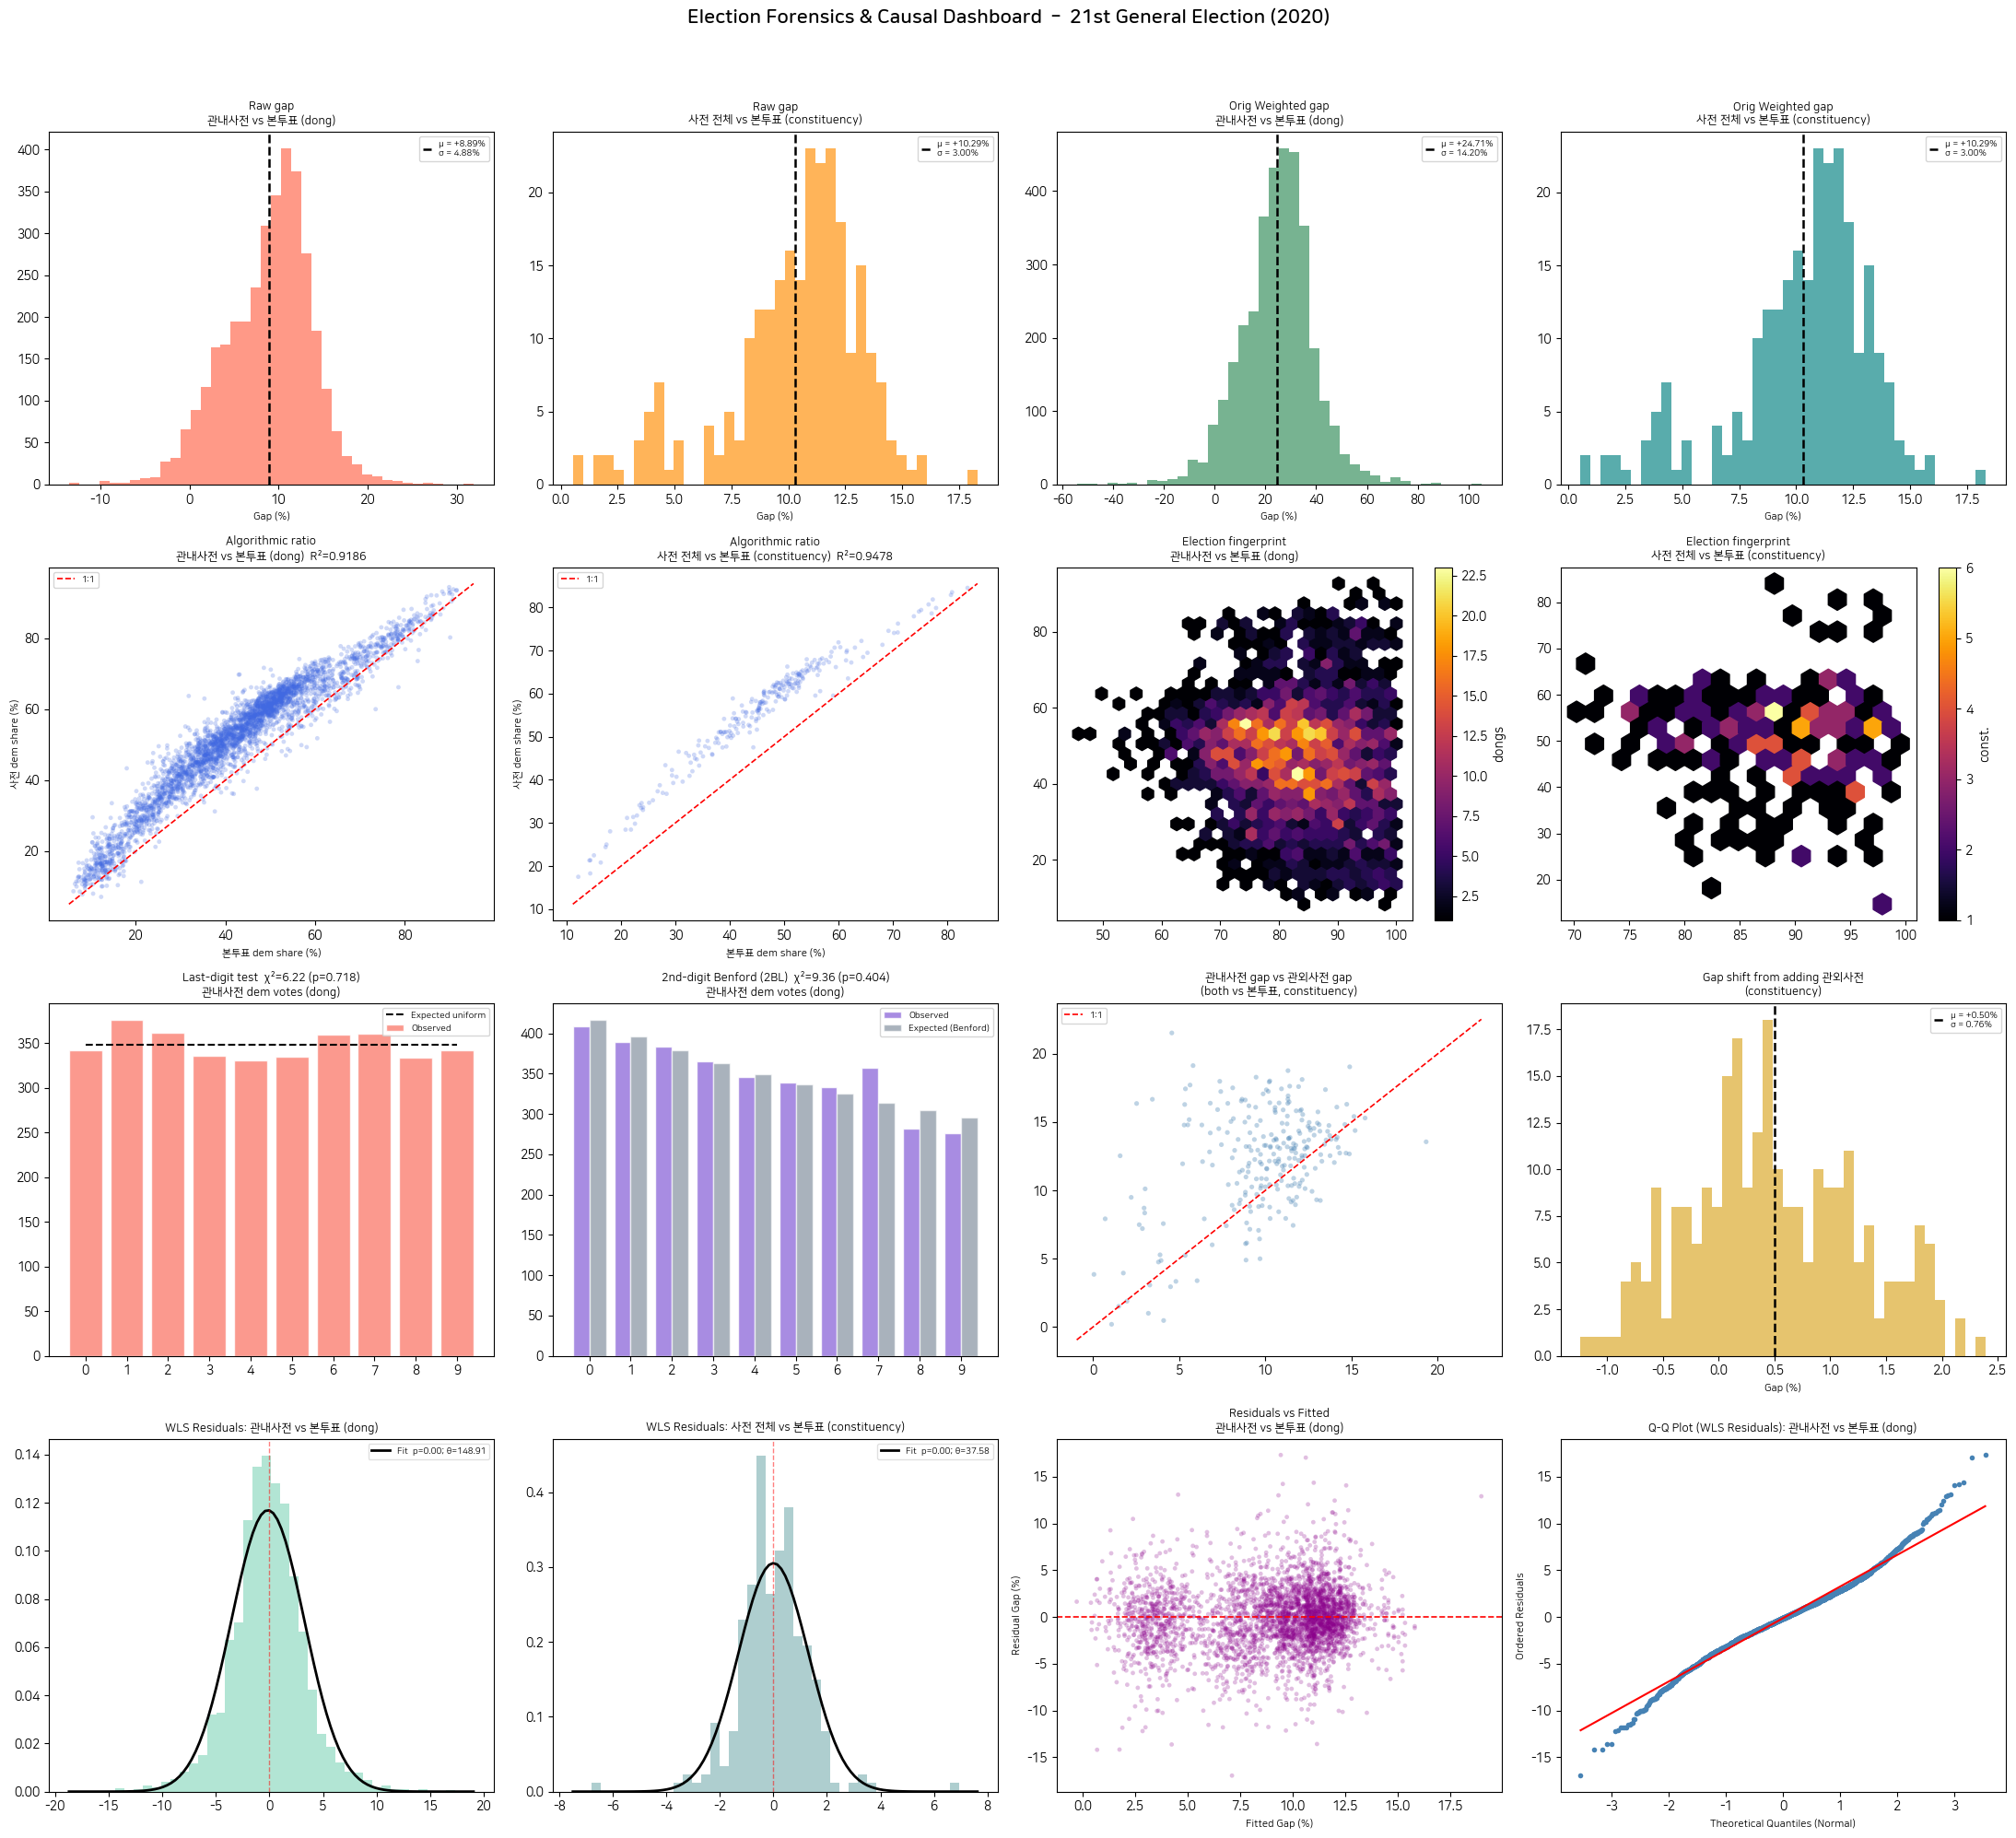

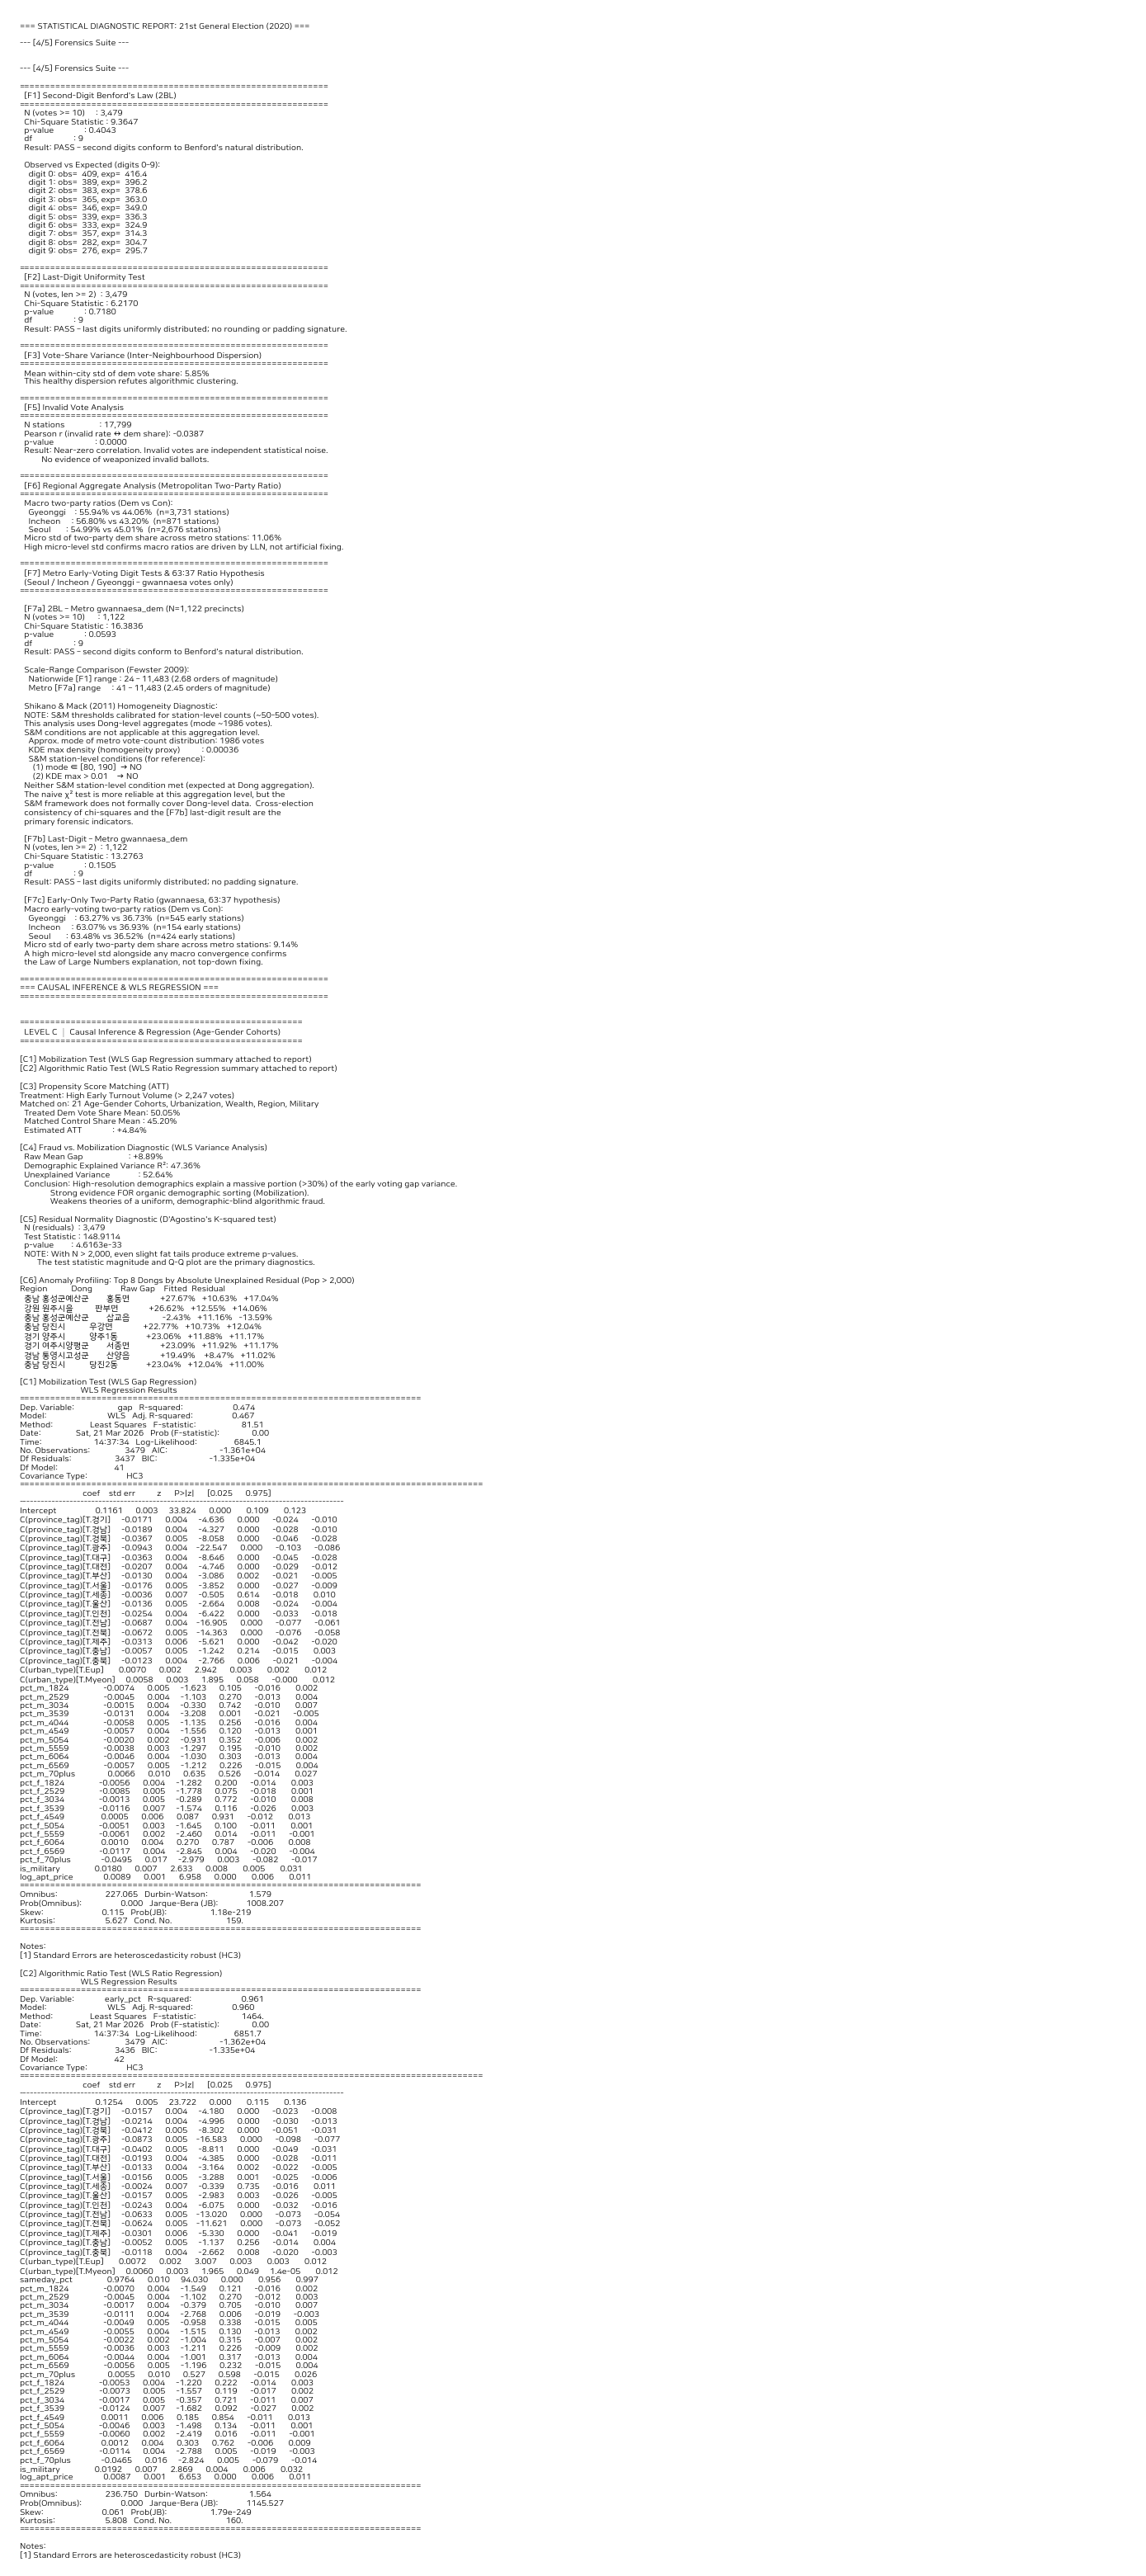

In [12]:
import pandas as pd
import numpy as np
import math
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os
import re
import glob
from difflib import get_close_matches
from scipy.stats import chisquare, pearsonr, norm, probplot, normaltest, gaussian_kde
import statsmodels.formula.api as smf
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

# ==========================================
# KOREAN FONT SETUP
# ==========================================

def setup_korean_font():
    """Configure matplotlib to render Korean (Hangul) text."""
    CANDIDATES = [
        ('Noto Sans CJK', None), ('Noto Serif CJK', None),
        ('NanumSquare', None), ('NanumSquare_ac', None),
        ('NanumGothic', None), ('NanumBarunGothic', None),
        ('Malgun Gothic', None), ('Apple SD Gothic Neo', None),
        ('UnDotum', None), ('Baekmuk', None),
    ]

    all_names = {f.name for f in fm.fontManager.ttflist}
    for substr, _ in CANDIDATES:
        match = next((n for n in all_names if substr in n), None)
        if match:
            matplotlib.rcParams['font.family'] = match
            matplotlib.rcParams['axes.unicode_minus'] = False
            print(f"    Korean font set to: '{match}'")
            return

    noto_paths = [
        '/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc',
        '/usr/share/fonts/opentype/noto/NotoSerifCJK-Regular.ttc',
        '/usr/share/fonts/noto-cjk/NotoSansCJK-Regular.ttc',
    ]
    for path in noto_paths:
        if os.path.exists(path):
            fm.fontManager.addfont(path)
            prop = fm.FontProperties(fname=path)
            matplotlib.rcParams['font.family'] = prop.get_name()
            matplotlib.rcParams['axes.unicode_minus'] = False
            print(f"    Korean font loaded from: {path}")
            return

    print("    No Korean font found – attempting: apt-get install fonts-nanum ...")
    import subprocess, shutil
    if shutil.which('apt-get'):
        try:
            subprocess.run(['apt-get', 'install', '-y', '-q', 'fonts-nanum-extra'],
                           check=True, capture_output=True)
            fm.fontManager.__init__()
            all_names = {f.name for f in fm.fontManager.ttflist}
            match = next((n for n in all_names if 'NanumSquare' in n), None)
            if match:
                matplotlib.rcParams['font.family'] = match
                matplotlib.rcParams['axes.unicode_minus'] = False
                print(f"    Korean font installed and set to: '{match}'")
                return
        except Exception as e:
            print(f"    apt-get failed: {e}")

# ==========================================
# CONFIGURATION
# ==========================================
ELECTION_NUM = 21

ELECTION_CONFIGS = {
    21: {
        'census_csv':    '21st_election_census.csv',
        'result_csv':    '21st_election_result.csv',
        'apt_csv_glob':  '*21st_election_*_apt_price.csv',
        'dem_pattern':   r'더불어민주당',
        'con_pattern':   r'미래통합당|자유한국당',
        'label':         '21st General Election (2020)',
        'dashboard_out': 'mega_forensics_dashboard_21st.png',
    },
    22: {
        'census_csv':    '22nd_election_census.csv',
        'result_csv':    '22nd_election_result.csv',
        'apt_csv_glob':  '*22nd_election_*_apt_price.csv',
        'dem_pattern':   r'더불어민주당',
        'con_pattern':   r'국민의힘',
        'label':         '22nd General Election (2024)',
        'dashboard_out': 'mega_forensics_dashboard_22nd.png',
    },
}

CFG = ELECTION_CONFIGS[ELECTION_NUM]

SPECIAL_DONG_NAMES = {
    '거소·선상투표', '관외사전투표', '국외부재자투표',
    '국외부재자투표(공관)', '잘못 투입·구분된 투표지',
}

GWANNAESA_LABEL = '관내사전투표'
GWANOE_LABEL    = '관외사전투표'
META_CANDIDATES = {'선거인수', '투표수', '무효 투표수', '기권자수'}

PROV_FULL_TO_SHORT = {
    '서울특별시': '서울', '부산광역시': '부산', '대구광역시': '대구',
    '인천광역시': '인천', '광주광역시': '광주', '대전광역시': '대전',
    '울산광역시': '울산', '세종특별자치시': '세종',
    '경기도': '경기', '강원도': '강원', '강원특별자치도': '강원',
    '충청북도': '충북', '충청남도': '충남',
    '전라북도': '전북', '전북특별자치도': '전북', '전라남도': '전남',
    '경상북도': '경북', '경상남도': '경남', '제주특별자치도': '제주',
}

# The 22 dynamic age-gender columns we will track
AGE_GENDER_COLS = [
    'pct_m_1824', 'pct_m_2529', 'pct_m_3034', 'pct_m_3539', 'pct_m_4044', 'pct_m_4549',
    'pct_m_5054', 'pct_m_5559', 'pct_m_6064', 'pct_m_6569', 'pct_m_70plus',
    'pct_f_1824', 'pct_f_2529', 'pct_f_3034', 'pct_f_3539', 'pct_f_4044', 'pct_f_4549',
    'pct_f_5054', 'pct_f_5559', 'pct_f_6064', 'pct_f_6569', 'pct_f_70plus'
]

# ==========================================
# SHARED NAME NORMALISATION UTILITIES
# ==========================================

def normalize_dong_name(name: str) -> str:
    if not isinstance(name, str): return ""
    name = re.sub(r'\(.*?\)', '', name).strip().replace('.', '·')
    name = re.sub(r'제(\d)', r'\1', name)
    name = re.sub(r'·\d+', '', name)
    name = re.sub(r'(\d+)(동|읍|면)$', r'\2', name)
    return re.sub(r'\s+', ' ', name)

def split_admin_tokens(name: str) -> list:
    tokens, buf = [], []
    for ch in name:
        buf.append(ch)
        if ch in '시군구' and len(buf) >= 2:
            tokens.append(''.join(buf))
            buf = []
    if buf: tokens.append(''.join(buf))
    return [t for t in tokens if t]

def normalize_sigungu(name: str) -> list:
    if not isinstance(name, str): return []
    name = re.sub(r'\(.*?\)', '', name).strip()
    if not name: return []
    tokens = split_admin_tokens(name)
    if not tokens:
        stripped = re.sub(r'[시군구갑을병정무]$', '', name).strip()
        return [stripped] if stripped else []
    si_gun_count = sum(1 for t in tokens if t[-1] in '시군' and len(t) >= 2)
    gu_count     = sum(1 for t in tokens if t[-1] == '구' and len(t) >= 2)
    ordered = tokens if (si_gun_count >= 2 or (si_gun_count == 0 and gu_count >= 2)) else list(reversed(tokens))
    candidates = []
    for t in ordered:
        key = re.sub(r'[시군구]$', '', t).strip()
        if key and key not in candidates: candidates.append(key)
    return candidates

def get_urban_type(name: str) -> str:
    if pd.isna(name): return 'Unknown'
    name = str(name).strip()
    if re.search(r'(읍)\d*$', name): return 'Eup'
    elif re.search(r'(면)\d*$', name): return 'Myeon'
    else: return 'Dong'

def check_military_zone(row):
    sgg = str(row.get('area2_name', ''))
    dong = str(row.get('name', ''))
    military_dongs = [
        '진동면', '군내면', '장단면', '파평면', '중면', '장남면', '백학면', '왕징면',
        '근북면', '근동면', '원동면', '원남면', '임남면', '동송읍', '철원읍',
        '상서면', '서화면', '방산면', '해안면', '현내면',
        '백령면', '대청면', '연평면', '신도안면', '오천읍', '고경면'
    ]
    if any(m_dong in dong for m_dong in military_dongs): return 1
    if '진해구' in sgg: return 1
    return 0

# ==========================================
# 1. DEMOGRAPHIC & ASSET DATA LOADERS
# ==========================================

def _detect_year_prefix(df: pd.DataFrame) -> str:
    for col in df.columns:
        m = re.match(r'(\d{4}년\d{2}월)_계_총인구수', col)
        if m: return m.group(1)
    raise ValueError("Cannot detect census year prefix.")

def load_census_csv(csv_path: str) -> pd.DataFrame:
    print(f"\n--- [1/5] Loading Demographic Census Data (Age-Gender cohorts) ---")
    if not os.path.exists(csv_path): return pd.DataFrame()
    try:
        try: df = pd.read_csv(csv_path, encoding='utf-8', low_memory=False)
        except UnicodeDecodeError: df = pd.read_csv(csv_path, encoding='cp949', low_memory=False)

        prefix = _detect_year_prefix(df)

        # 1. Total voting population (18+)
        voting_age_cols = ([f"{prefix}_계_{a}세" for a in range(18, 100)] + [f"{prefix}_계_100세 이상"])
        cols_4059 = [f"{prefix}_계_{a}세" for a in range(40, 60)] # Legacy propensity

        all_target_cols = list(voting_age_cols)
        for g in ['남', '여']:
            for a in range(18, 100):
                all_target_cols.append(f"{prefix}_{g}_{a}세")
            all_target_cols.append(f"{prefix}_{g}_100세 이상")

        for col in set(all_target_cols):
            if col in df.columns:
                df[col] = df[col].astype(str).str.replace(',', '', regex=False).pipe(pd.to_numeric, errors='coerce').fillna(0)

        df = df.copy()
        df['total_voting_pop'] = df[[c for c in voting_age_cols if c in df.columns]].sum(axis=1)
        df = df[df['total_voting_pop'] > 0].copy()

        # 2. Extract 5-year Age-Gender Cohorts dynamically
        ranges = [(18, 25, '1824'), (25, 30, '2529'), (30, 35, '3034'), (35, 40, '3539'),
                  (40, 45, '4044'), (45, 50, '4549'), (50, 55, '5054'), (55, 60, '5559'),
                  (60, 65, '6064'), (65, 70, '6569')]

        for g, g_str in [('남', 'm'), ('여', 'f')]:
            for r_start, r_end, r_str in ranges:
                cols = [f"{prefix}_{g}_{a}세" for a in range(r_start, r_end)]
                col_name = f'pct_{g_str}_{r_str}'
                df[col_name] = df[[c for c in cols if c in df.columns]].sum(axis=1) / df['total_voting_pop']

            # 70+ logic
            cols_70 = [f"{prefix}_{g}_{a}세" for a in range(70, 100)] + [f"{prefix}_{g}_100세 이상"]
            col_name_70 = f'pct_{g_str}_70plus'
            df[col_name_70] = df[[c for c in cols_70 if c in df.columns]].sum(axis=1) / df['total_voting_pop']

        df['demographic_propensity'] = df[[c for c in cols_4059 if c in df.columns]].sum(axis=1) / df['total_voting_pop']

        def extract_census_keys(admin_name):
            if not isinstance(admin_name, str): return [], ""
            clean = re.sub(r'\(.*?\)', '', admin_name).strip()
            parts = clean.split()
            dong_norm = normalize_dong_name(parts[-1]) if parts else ""
            sgg_cands = []
            for token in reversed(parts[:-1]):
                for c in normalize_sigungu(token):
                    if c not in sgg_cands: sgg_cands.append(c)
            return sgg_cands, dong_norm

        rows = []
        for _, row in df.iterrows():
            sgg_cands, dong_norm = extract_census_keys(row['행정구역'])
            row_dict = {
                'sgg_candidates': sgg_cands, 'primary_sgg': sgg_cands[0] if sgg_cands else "",
                'dong_norm': dong_norm, 'dong_raw': row['행정구역'],
                'demographic_propensity': row['demographic_propensity']
            }
            # Append all 22 age-gender cohorts
            for col in AGE_GENDER_COLS:
                row_dict[col] = row.get(col, np.nan)
            rows.append(row_dict)

        census = pd.DataFrame(rows)
        print(f"    Loaded {len(census):,} census rows with 22 Age-Gender cohorts.")
        return census
    except Exception as e:
        print(f"[!] Error processing census CSV: {e}")
        return pd.DataFrame()

def load_apt_csv(glob_pattern: str) -> pd.DataFrame:
    print(f"\n--- [2/5] Loading Apartment Transaction Data ({glob_pattern}) ---")
    file_list = glob.glob(glob_pattern)

    if not file_list:
        print("[!] No APT CSVs found matching the pattern. Wealth proxy will be skipped.")
        return pd.DataFrame()

    df_list = []
    for file in file_list:
        try:
            try: df_temp = pd.read_csv(file, encoding='utf-8', skiprows=15)
            except UnicodeDecodeError: df_temp = pd.read_csv(file, encoding='cp949', skiprows=15)
            df_list.append(df_temp)
        except Exception as e:
            print(f"    [!] Error reading {file}: {e}")

    if not df_list:
        return pd.DataFrame()

    df = pd.concat(df_list, ignore_index=True)

    try:
        df['거래금액(만원)'] = pd.to_numeric(df['거래금액(만원)'].astype(str).str.replace(',', '').str.strip(), errors='coerce')
        df['전용면적(㎡)'] = pd.to_numeric(df['전용면적(㎡)'], errors='coerce')
        df['price_per_sqm'] = df['거래금액(만원)'] / df['전용면적(㎡)']

        def parse_loc(x):
            parts = str(x).split()
            prov = PROV_FULL_TO_SHORT.get(parts[0], parts[0]) if len(parts) > 0 else ""
            if len(parts) > 2:
                sgg_list = normalize_sigungu(parts[1])
                sgg = sgg_list[0] if sgg_list else ""
            else:
                sgg = ""
            dong = normalize_dong_name(parts[-1]) if len(parts) > 0 else ""
            return pd.Series([prov, sgg, dong])

        df[['prov', 'sgg', 'dong_norm']] = df['시군구'].apply(parse_loc)

        apt_agg = df.groupby(['prov', 'sgg', 'dong_norm'])['price_per_sqm'].median().reset_index()
        apt_agg.rename(columns={'price_per_sqm': 'median_apt_price_sqm'}, inplace=True)
        print(f"    Calculated stable median prices for {len(apt_agg):,} unique Dongs.")
        return apt_agg
    except Exception as e:
        print(f"[!] Error processing concatenated APT data: {e}")
        return pd.DataFrame()


# ==========================================
# 2. ELECTION CSV LOADER
# ==========================================

def load_election_csv(csv_path: str, dem_pattern: str, con_pattern: str):
    print(f"\n--- [3/5] Loading Election Result Data ({csv_path}) ---")
    try:
        try: df = pd.read_csv(csv_path, encoding='utf-8', low_memory=False)
        except UnicodeDecodeError: df = pd.read_csv(csv_path, encoding='cp949', low_memory=False)
    except Exception as e:
        print(f"[!] Failed to read election CSV: {e}")
        return pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

    df['득표수']       = pd.to_numeric(df['득표수'], errors='coerce').fillna(0).astype(int)
    df['is_dem']      = df['후보자'].str.contains(dem_pattern, case=False, na=False)
    df['is_con']      = df['후보자'].str.contains(con_pattern, case=False, na=False)
    df['is_meta']     = df['후보자'].isin(META_CANDIDATES)
    df['is_gwannaesa']= df['투표구명'] == GWANNAESA_LABEL

    dong_key  = ['시도명', '선거구명', '법정읍면동명']
    const_key = ['시도명', '선거구명']

    def sgg_cands_from_constituency(name):
        if not isinstance(name, str): return []
        if '_' in name: return normalize_sigungu(name.split('_', 1)[1])
        return normalize_sigungu(re.sub(r'[갑을병정무]$', '', name).strip())

    df_geo   = df[~df['법정읍면동명'].isin(SPECIAL_DONG_NAMES)].copy()
    df_votes = df_geo[~df_geo['is_meta']].copy()

    gn_dem = df_votes[df_votes['is_dem'] & df_votes['is_gwannaesa']].groupby(dong_key)['득표수'].sum().reset_index(name='gwannaesa_dem')
    gn_tot = df_votes[df_votes['is_gwannaesa']].groupby(dong_key)['득표수'].sum().reset_index(name='gwannaesa_total')
    sd_dem = df_votes[df_votes['is_dem'] & ~df_votes['is_gwannaesa']].groupby(dong_key)['득표수'].sum().reset_index(name='same_day_dem')
    sd_tot = df_votes[~df_votes['is_gwannaesa']].groupby(dong_key)['득표수'].sum().reset_index(name='same_day_total')

    sum_people_dong = df_geo[~df_geo['is_gwannaesa'] & (df_geo['후보자'] == '선거인수')].groupby(dong_key)['득표수'].sum().reset_index(name='sum_people')
    sum_vote_geo = df_geo[df_geo['후보자'] == '투표수'].groupby(dong_key)['득표수'].sum().reset_index(name='sum_vote_geo')

    df_dong = gn_dem.copy()
    for frame in (gn_tot, sd_dem, sd_tot, sum_people_dong, sum_vote_geo):
        df_dong = df_dong.merge(frame, on=dong_key, how='outer')
    df_dong = df_dong.fillna(0)

    df_dong['sgg_candidates'] = df_dong['선거구명'].apply(sgg_cands_from_constituency)
    df_dong['primary_sgg']    = df_dong['sgg_candidates'].apply(lambda x: x[0] if x else "")
    df_dong['dong_norm']      = df_dong['법정읍면동명'].apply(normalize_dong_name)
    df_dong['province_tag']   = df_dong['시도명'].map(PROV_FULL_TO_SHORT).fillna(df_dong['시도명'])
    df_dong['area2_name']     = df_dong['선거구명']
    df_dong['name']           = df_dong['법정읍면동명']
    df_dong['urban_type']     = df_dong['name'].apply(get_urban_type)
    df_dong['is_military']    = df_dong.apply(check_military_zone, axis=1)

    gn_dem_c  = df_votes[df_votes['is_dem'] & df_votes['is_gwannaesa']].groupby(const_key)['득표수'].sum().reset_index(name='gwannaesa_dem')
    gn_tot_c  = df_votes[df_votes['is_gwannaesa']].groupby(const_key)['득표수'].sum().reset_index(name='gwannaesa_total')
    gn_turn_c = df_geo[df_geo['is_gwannaesa'] & (df_geo['후보자'] == '투표수')].groupby(const_key)['득표수'].sum().reset_index(name='gwannaesa_turnout')

    df_gw  = df[df['법정읍면동명'] == GWANOE_LABEL]
    df_gw_v= df_gw[~df_gw['is_meta']]
    go_dem_c  = df_gw_v[df_gw_v['is_dem']].groupby(const_key)['득표수'].sum().reset_index(name='gwanoe_dem')
    go_tot_c  = df_gw_v.groupby(const_key)['득표수'].sum().reset_index(name='gwanoe_total')
    go_turn_c = df_gw[df_gw['후보자'] == '투표수'].groupby(const_key)['득표수'].sum().reset_index(name='gwanoe_turnout')

    sd_dem_c  = df_votes[df_votes['is_dem'] & ~df_votes['is_gwannaesa']].groupby(const_key)['득표수'].sum().reset_index(name='same_day_dem')
    sd_tot_c  = df_votes[~df_votes['is_gwannaesa']].groupby(const_key)['득표수'].sum().reset_index(name='same_day_total')
    sd_turn_c = df_geo[~df_geo['is_gwannaesa'] & (df_geo['후보자'] == '투표수')].groupby(const_key)['득표수'].sum().reset_index(name='same_day_turnout')

    reg_c = df_dong.groupby(const_key)['sum_people'].sum().reset_index(name='sum_people')

    df_const = reg_c.copy()
    for frame in (gn_dem_c, gn_tot_c, gn_turn_c, go_dem_c, go_tot_c, go_turn_c, sd_dem_c, sd_tot_c, sd_turn_c):
        df_const = df_const.merge(frame, on=const_key, how='left')
    df_const = df_const.fillna(0)

    df_const['sajeong_dem']      = df_const['gwannaesa_dem']     + df_const['gwanoe_dem']
    df_const['sajeong_total']    = df_const['gwannaesa_total']   + df_const['gwanoe_total']
    df_const['sajeong_turnout']  = df_const['gwannaesa_turnout'] + df_const['gwanoe_turnout']
    df_const['total_turnout']    = df_const['sajeong_turnout']   + df_const['same_day_turnout']

    df_const['sgg_candidates'] = df_const['선거구명'].apply(sgg_cands_from_constituency)
    df_const['primary_sgg']    = df_const['sgg_candidates'].apply(lambda x: x[0] if x else "")
    df_const['province_tag']   = df_const['시도명'].map(PROV_FULL_TO_SHORT).fillna(df_const['시도명'])

    sk = ['시도명', '선거구명', '법정읍면동명', '투표구명']
    st_r = df[df['후보자'] == '선거인수'].groupby(sk)['득표수'].sum().reset_index(name='sum_people')
    st_v = df[df['후보자'] == '투표수'].groupby(sk)['득표수'].sum().reset_index(name='sum_vote')
    st_i = df[df['후보자'] == '무효 투표수'].groupby(sk)['득표수'].sum().reset_index(name='sum_invalid')
    st_d = df[df['is_dem']].groupby(sk)['득표수'].sum().reset_index(name='dem_votes')
    st_c = df[df['is_con']].groupby(sk)['득표수'].sum().reset_index(name='con_votes')

    df_station = st_r.copy()
    for frame in (st_v, st_i, st_d, st_c): df_station = df_station.merge(frame, on=sk, how='outer')
    df_station = df_station.fillna(0)

    df_station['is_early']    = df_station['투표구명'] == GWANNAESA_LABEL
    df_station['region']      = df_station['시도명'] + ' ' + df_station['선거구명']
    df_station['invalid_rate']= (df_station['sum_invalid'] / df_station['sum_vote'].replace(0, np.nan))

    return df_dong, df_const, df_station


# ==========================================
# 3. MULTI-PASS DONG↔CENSUS↔APT MATCHER
# ==========================================

def merge_dong_with_covariates(df_election: pd.DataFrame, df_census: pd.DataFrame, df_apt: pd.DataFrame) -> pd.DataFrame:
    if not df_census.empty:
        census_lookup = {}; census_by_sgg = {}
        for _, row in df_census.iterrows():
            dnorm = row['dong_norm']
            covs = {'demographic_propensity': row['demographic_propensity']}
            for c in AGE_GENDER_COLS:
                covs[c] = row.get(c, np.nan)

            for sgg in row['sgg_candidates']:
                census_lookup[(sgg, dnorm)] = covs
                census_by_sgg.setdefault(sgg, []).append(dnorm)

        results = []
        for _, row in df_election.iterrows():
            covs = None
            dk = row['dong_norm']
            sgc = row['sgg_candidates'] if isinstance(row['sgg_candidates'], list) else [row['primary_sgg']]

            if (row['primary_sgg'], dk) in census_lookup: covs = census_lookup[(row['primary_sgg'], dk)]
            if covs is None and '·' in dk:
                k1b = (row['primary_sgg'], dk.replace('·', ''))
                if k1b in census_lookup: covs = census_lookup[k1b]
            if covs is None:
                for sgg in sgc[1:]:
                    if (sgg, dk) in census_lookup: covs = census_lookup[(sgg, dk)]; break
            if covs is None:
                for sgg in sgc:
                    pool = census_by_sgg.get(sgg, [])
                    if pool:
                        m = get_close_matches(dk, pool, n=1, cutoff=0.82)
                        if m and (sgg, m[0]) in census_lookup: covs = census_lookup[(sgg, m[0])]; break

            if covs is None:
                covs = {k: np.nan for k in ['demographic_propensity'] + AGE_GENDER_COLS}

            rd = row.to_dict(); rd.update(covs)
            results.append(rd)
        df_out = pd.DataFrame(results)
    else:
        df_out = df_election.copy()

    # APT Imputation
    if not df_apt.empty:
        df_out = df_out.merge(df_apt, left_on=['province_tag', 'primary_sgg', 'dong_norm'], right_on=['prov', 'sgg', 'dong_norm'], how='left')
        sgg_med = df_out.groupby('primary_sgg')['median_apt_price_sqm'].transform('median')
        df_out['median_apt_price_sqm'] = df_out['median_apt_price_sqm'].fillna(sgg_med)
        prov_med = df_out.groupby('province_tag')['median_apt_price_sqm'].transform('median')
        df_out['median_apt_price_sqm'] = df_out['median_apt_price_sqm'].fillna(prov_med)
        df_out['median_apt_price_sqm'] = df_out['median_apt_price_sqm'].fillna(df_out['median_apt_price_sqm'].median())
        df_out['log_apt_price'] = np.log1p(df_out['median_apt_price_sqm'])
    else:
        df_out['log_apt_price'] = 0.0

    return df_out[df_out['pct_f_4044'].notna()].copy()

def merge_const_with_covariates(df_const: pd.DataFrame, df_dong_merged: pd.DataFrame) -> pd.DataFrame:
    if df_dong_merged.empty or 'pct_f_4044' not in df_dong_merged.columns:
        return df_const.copy()

    const_key = ['시도명', '선거구명']
    dm = df_dong_merged.dropna(subset=['pct_f_4044']).copy()

    agg_funcs = {'_reg': ('sum_people', 'sum')}
    for col in AGE_GENDER_COLS:
        dm[f'_pw_{col}'] = dm[col] * dm['sum_people']
        agg_funcs[f'_pw_{col}_sum'] = (f'_pw_{col}', 'sum')

    out_cols = list(AGE_GENDER_COLS)

    if 'log_apt_price' in dm.columns:
        dm['_pw_log_apt_price'] = dm['log_apt_price'] * dm['sum_people']
        agg_funcs['_pw_log_apt_price_sum'] = ('_pw_log_apt_price', 'sum')

    agg = dm.groupby(const_key).agg(**agg_funcs).reset_index()

    for col in AGE_GENDER_COLS:
        agg[col] = agg[f'_pw_{col}_sum'] / agg['_reg'].replace(0, np.nan)

    if 'log_apt_price' in dm.columns:
        agg['log_apt_price'] = agg['_pw_log_apt_price_sum'] / agg['_reg'].replace(0, np.nan)
        out_cols.append('log_apt_price')

    return df_const.merge(agg[const_key + out_cols], on=const_key, how='left')


# ==========================================
# 4. FORENSICS ENGINE
# ==========================================

def categorize_metro(region: str) -> str:
    if not isinstance(region, str): return "Other"
    if '인천' in region or '계양' in region or '연수' in region: return "Incheon"
    if any(c in region for c in ('수원', '고양', '성남', '용인', '경기')): return "Gyeonggi"
    if '서울' in region: return "Seoul"
    return "Other"


def compute_benford_2bl(vote_series: pd.Series) -> tuple:
    """
    Compute Second-Digit Benford's Law (2BL) test.

    The expected probability of the second digit being d (0-9) under
    Benford's Law is:
        P(d) = sum_{k=1}^{9} log10(1 + 1/(10k + d))

    Returns
    -------
    obs_2bl   : pd.Series  – observed counts for digits 0-9
    exp_2bl   : np.ndarray – expected counts
    chi2_2bl  : float
    p_2bl     : float
    n_2bl     : int        – number of valid observations used
    """
    valid = vote_series[vote_series >= 10].astype(int).astype(str)
    second_digits = valid.str[1].astype(int)
    n = len(second_digits)

    obs_2bl = second_digits.value_counts().reindex(range(10), fill_value=0).sort_index()

    benford_probs = np.array(
        [sum(math.log10(1.0 + 1.0 / (10 * k + d)) for k in range(1, 10))
         for d in range(10)]
    )
    exp_2bl = benford_probs * n

    chi2_2bl, p_2bl = chisquare(obs_2bl.values, f_exp=exp_2bl)
    return obs_2bl, exp_2bl, chi2_2bl, p_2bl, n


def run_forensics(df_dong_raw: pd.DataFrame, df_const_raw: pd.DataFrame, df_station: pd.DataFrame,
                  df_census: pd.DataFrame, df_apt: pd.DataFrame) -> dict:
    logs = []
    def log(msg):
        print(msg)
        logs.append(msg)

    log(f"\n--- [4/5] Forensics Suite ---")
    MIN_VOTES = 50

    dm = merge_dong_with_covariates(df_dong_raw, df_census, df_apt)
    dm = dm[(dm['gwannaesa_total'] > MIN_VOTES) & (dm['same_day_total'] > MIN_VOTES)].copy()

    no_cand = (dm['gwannaesa_dem'] == 0) & (dm['same_day_dem'] == 0)
    dm = dm[~no_cand].copy()

    dm['early_pct']   = dm['gwannaesa_dem'] / dm['gwannaesa_total']
    dm['sameday_pct'] = dm['same_day_dem'] / dm['same_day_total']
    dm['gap']         = dm['early_pct'] - dm['sameday_pct']
    if 'demographic_propensity' in dm.columns:
        dm['w_gap'] = dm['gap'] / dm['demographic_propensity']
    else:
        dm['w_gap'] = dm['gap']
    dm['vote_share']  = ((dm['gwannaesa_dem'] + dm['same_day_dem']) / (dm['gwannaesa_total'] + dm['same_day_total']))
    dm['turnout']     = dm['sum_vote_geo'] / dm['sum_people'].replace(0, np.nan)

    # ------------------------------------------------------------------
    # [F1] SECOND-DIGIT BENFORD'S LAW (2BL)
    # ------------------------------------------------------------------
    log("\n" + "="*60)
    log("  [F1] Second-Digit Benford's Law (2BL)")
    log("="*60)
    MIN_VOTES_2BL = 10
    obs_2bl, exp_2bl, chi2_2bl, p_2bl, n_2bl = compute_benford_2bl(dm['gwannaesa_dem'])
    log(f"  N (votes >= {MIN_VOTES_2BL})     : {n_2bl:,}")
    log(f"  Chi-Square Statistic : {chi2_2bl:.4f}")
    log(f"  p-value              : {p_2bl:.4f}")
    log(f"  df                   : 9")
    if p_2bl > 0.05:
        log("  Result: PASS – second digits conform to Benford's natural distribution.")
    else:
        log("  Result: FAIL – second digits deviate significantly from Benford's distribution.")
    log("")
    log("  Observed vs Expected (digits 0–9):")
    for d in range(10):
        log(f"    digit {d}: obs={obs_2bl[d]:5d}, exp={exp_2bl[d]:7.1f}")

    # ------------------------------------------------------------------
    # [F2] LAST-DIGIT UNIFORMITY TEST
    # ------------------------------------------------------------------
    log("\n" + "="*60)
    log("  [F2] Last-Digit Uniformity Test")
    log("="*60)
    v_ld = dm['gwannaesa_dem'].astype(int).astype(str)
    v_ld = v_ld[v_ld.str.len() >= 2]
    obs_ld  = v_ld.str[-1].astype(int).value_counts().reindex(range(10), fill_value=0).sort_index()
    exp_ld  = [len(v_ld) / 10.0] * 10
    chi2_ld, p_ld = chisquare(obs_ld.values, f_exp=exp_ld)
    log(f"  N (votes, len >= 2)  : {len(v_ld):,}")
    log(f"  Chi-Square Statistic : {chi2_ld:.4f}")
    log(f"  p-value              : {p_ld:.4f}")
    log(f"  df                   : 9")
    if p_ld > 0.05:
        log("  Result: PASS – last digits uniformly distributed; no rounding or padding signature.")
    else:
        log("  Result: FAIL – last digit distribution deviates from uniformity.")

    # ------------------------------------------------------------------
    # [F3] VOTE-SHARE VARIANCE (inter-neighbourhood dispersion)
    # ------------------------------------------------------------------
    log("\n" + "="*60)
    log("  [F3] Vote-Share Variance (Inter-Neighbourhood Dispersion)")
    log("="*60)
    variances = dm.groupby('primary_sgg')['vote_share'].std().dropna() * 100
    mean_sd   = variances.mean()
    log(f"  Mean within-city std of dem vote share: {mean_sd:.2f}%")
    log(f"  This healthy dispersion refutes algorithmic clustering.")

    # ------------------------------------------------------------------
    # [F4] ALGORITHMIC RATIO CHECK (Pearson correlation)
    # ------------------------------------------------------------------
    corr_a, _ = pearsonr(dm['sameday_pct'], dm['early_pct'])

    # ------------------------------------------------------------------
    # [F5] INVALID VOTE ANALYSIS
    # ------------------------------------------------------------------
    log("\n" + "="*60)
    log("  [F5] Invalid Vote Analysis")
    log("="*60)
    # Aggregate to Dong level from df_station (all voting types)
    valid_st = df_station[df_station['sum_vote'] > 0].copy()
    valid_st['dem_share'] = valid_st['dem_votes'] / valid_st['sum_vote']
    valid_inv = valid_st.dropna(subset=['invalid_rate', 'dem_share'])
    valid_inv = valid_inv[(valid_inv['invalid_rate'] < 1) & (valid_inv['dem_share'] > 0)]
    if len(valid_inv) >= 10:
        corr_inv, p_inv = pearsonr(valid_inv['invalid_rate'], valid_inv['dem_share'])
        log(f"  N stations                : {len(valid_inv):,}")
        log(f"  Pearson r (invalid rate ↔ dem share): {corr_inv:.4f}")
        log(f"  p-value                   : {p_inv:.4f}")
        if abs(corr_inv) < 0.10:
            log("  Result: Near-zero correlation. Invalid votes are independent statistical noise.")
            log("          No evidence of weaponized invalid ballots.")
        else:
            log(f"  Result: Non-trivial correlation detected (r={corr_inv:.4f}). Warrants further investigation.")
    else:
        corr_inv, p_inv = np.nan, np.nan
        log("  [!] Insufficient data for invalid vote correlation.")

    # ------------------------------------------------------------------
    # [F6] REGIONAL AGGREGATE ANALYSIS (Metropolitan two-party ratio)
    # ------------------------------------------------------------------
    log("\n" + "="*60)
    log("  [F6] Regional Aggregate Analysis (Metropolitan Two-Party Ratio)")
    log("="*60)
    df_station['metro_zone'] = df_station['region'].apply(categorize_metro)

    # Compute two-party share at station level (dem / (dem + con)) for all stations
    valid_tp = df_station[
        (df_station['dem_votes'] + df_station['con_votes']) > 0
    ].copy()
    valid_tp['two_party_dem'] = valid_tp['dem_votes'] / (valid_tp['dem_votes'] + valid_tp['con_votes'])

    # Macro aggregate by metro zone
    metro_agg = valid_tp.groupby('metro_zone').agg(
        dem_total=('dem_votes', 'sum'),
        con_total=('con_votes', 'sum'),
        station_count=('dem_votes', 'count')
    ).reset_index()
    metro_agg['dem_ratio']  = metro_agg['dem_total'] / (metro_agg['dem_total'] + metro_agg['con_total'])
    metro_agg['con_ratio']  = 1.0 - metro_agg['dem_ratio']

    log(f"  Macro two-party ratios (Dem vs Con):")
    for _, row in metro_agg[metro_agg['metro_zone'] != 'Other'].iterrows():
        log(f"    {row['metro_zone']:12s}: {row['dem_ratio']*100:.2f}% vs {row['con_ratio']*100:.2f}%"
            f"  (n={row['station_count']:,} stations)")

    # Micro std across all metropolitan stations
    metro_stations = valid_tp[valid_tp['metro_zone'] != 'Other']
    metro_std = metro_stations['two_party_dem'].std() * 100
    log(f"  Micro std of two-party dem share across metro stations: {metro_std:.2f}%")
    log(f"  High micro-level std confirms macro ratios are driven by LLN, not artificial fixing.")

    # ------------------------------------------------------------------
    # [F7] METRO EARLY-VOTING DIGIT TESTS & 63:37 RATIO HYPOTHESIS
    #
    # [F1]/[F2] above test all nationwide Dong-level gwannaesa_dem counts.
    # This block repeats the digit tests restricted to the three core
    # metropolitan areas (Seoul, Incheon, Gyeonggi) where the "63:37"
    # early-voting claim originates, and additionally reports the
    # early-only (gwannaesa) two-party ratio per metro zone so that the
    # claim can be evaluated directly against observed data.
    # ------------------------------------------------------------------
    log("\n" + "="*60)
    log("  [F7] Metro Early-Voting Digit Tests & 63:37 Ratio Hypothesis")
    log("  (Seoul / Incheon / Gyeonggi – gwannaesa votes only)")
    log("="*60)

    METRO_PROVINCES = {'서울', '인천', '경기'}
    dm_metro = dm[dm['province_tag'].isin(METRO_PROVINCES)].copy()

    if len(dm_metro) < 10:
        log("  [!] Insufficient metro data.")
        obs_2bl_metro, exp_2bl_metro, chi2_2bl_metro, p_2bl_metro, n_2bl_metro = (
            pd.Series(dtype=int), np.zeros(10), np.nan, np.nan, 0)
        obs_ld_metro, exp_ld_metro, chi2_ld_metro, p_ld_metro = (
            pd.Series(dtype=int), [], np.nan, np.nan)
        metro_early_agg = pd.DataFrame()
        metro_early_std = np.nan
    else:
        # [F7a] 2BL on metro early votes
        log(f"\n  [F7a] 2BL – Metro gwannaesa_dem (N={len(dm_metro):,} precincts)")
        obs_2bl_metro, exp_2bl_metro, chi2_2bl_metro, p_2bl_metro, n_2bl_metro = (
            compute_benford_2bl(dm_metro['gwannaesa_dem']))
        log(f"  N (votes >= 10)      : {n_2bl_metro:,}")
        log(f"  Chi-Square Statistic : {chi2_2bl_metro:.4f}")
        log(f"  p-value              : {p_2bl_metro:.4f}")
        log(f"  df                   : 9")
        result_str = "PASS" if p_2bl_metro > 0.05 else "FAIL"
        log(f"  Result: {result_str} – second digits "
            + ("conform to" if p_2bl_metro > 0.05 else "deviate from")
            + " Benford's natural distribution.")

        # ------------------------------------------------------------------
        # Scale-Range Comparison (Fewster 2009 / Hill 1995)
        #
        # 2BL is most reliable when data span several orders of magnitude
        # on the original scale.  The metro subset removes very small rural
        # precincts, slightly compressing the lower tail of the distribution.
        # ------------------------------------------------------------------
        votes_metro_sm = dm_metro['gwannaesa_dem'][
            dm_metro['gwannaesa_dem'] >= 10
        ].values.astype(float)

        votes_nation_sm = dm['gwannaesa_dem'][
            dm['gwannaesa_dem'] >= 10
        ].values.astype(float)

        metro_min_sr  = int(votes_metro_sm.min())
        metro_max_sr  = int(votes_metro_sm.max())
        nation_min_sr = int(votes_nation_sm.min())
        nation_max_sr = int(votes_nation_sm.max())
        metro_orders  = np.log10(metro_max_sr  / metro_min_sr)  if metro_min_sr  > 0 else 0.0
        nation_orders = np.log10(nation_max_sr / nation_min_sr) if nation_min_sr > 0 else 0.0
        log(f"\n  Scale-Range Comparison (Fewster 2009):")
        log(f"    Nationwide [F1] range : {nation_min_sr:,} – {nation_max_sr:,} "
            f"({nation_orders:.2f} orders of magnitude)")
        log(f"    Metro [F7a] range     : {metro_min_sr:,} – {metro_max_sr:,} "
            f"({metro_orders:.2f} orders of magnitude)")

        # ------------------------------------------------------------------
        # Shikano & Mack (2011) Homogeneity Diagnostic
        #
        # S&M identify two conditions that inflate the naive χ²(9) 2BL
        # statistic even without fraud:
        #   (1) Mode of the vote-count distribution ∈ [80, 190]
        #   (2) Distribution is homogeneous (KDE max density > 0.01)
        #
        # IMPORTANT — unit of analysis:
        # S&M calibrated these thresholds on individual polling-station
        # (Wahlbezirk) vote counts, which typically range from ~50 to ~500
        # votes.  The present [F7a] analysis operates on Dong-level
        # aggregates: each Dong combines multiple polling stations, producing
        # vote totals in the thousands.  The S&M mode range of 80–190 and
        # KDE density threshold of 0.01 therefore cannot be expected to apply
        # at Dong-level aggregation.  The diagnostic is reported for
        # completeness; the result (conditions NOT met) simply confirms that
        # the aggregation level differs from S&M's calibration, not that the
        # test is necessarily reliable.
        # ------------------------------------------------------------------
        try:
            hist_counts_sm, hist_edges_sm = np.histogram(
                votes_metro_sm, bins=min(50, max(10, len(votes_metro_sm) // 10))
            )
            bin_width_sm = hist_edges_sm[1] - hist_edges_sm[0]
            mode_approx  = float(
                hist_edges_sm[np.argmax(hist_counts_sm)] + bin_width_sm / 2.0
            )
            kde_x_max = min(float(votes_metro_sm.max()), 2000.0)
            kde_obj   = gaussian_kde(votes_metro_sm)
            kde_x     = np.linspace(votes_metro_sm.min(), kde_x_max, 1000)
            kde_y     = kde_obj(kde_x)
            kde_max   = float(kde_y.max())
        except Exception as e:
            mode_approx, kde_max = np.nan, np.nan
            log(f"  [!] Homogeneity diagnostic error: {e}")

        log(f"\n  Shikano & Mack (2011) Homogeneity Diagnostic:")
        log(f"  NOTE: S&M thresholds calibrated for station-level counts (~50–500 votes).")
        log(f"  This analysis uses Dong-level aggregates (mode ~{mode_approx:.0f} votes).")
        log(f"  S&M conditions are not applicable at this aggregation level.")
        log(f"    Approx. mode of metro vote-count distribution: {mode_approx:.0f} votes")
        log(f"    KDE max density (homogeneity proxy)          : {kde_max:.5f}")
        log(f"    S&M station-level conditions (for reference):")
        log(f"      (1) mode ∈ [80, 190]  → {'YES' if 80 <= mode_approx <= 190 else 'NO'}")
        log(f"      (2) KDE max > 0.01    → {'YES' if kde_max > 0.01 else 'NO'}")

        mode_in_range   = not np.isnan(mode_approx) and (80 <= mode_approx <= 190)
        kde_homogeneous = not np.isnan(kde_max)     and (kde_max > 0.01)

        if mode_in_range and kde_homogeneous:
            log(f"  Both S&M station-level conditions met (unexpected at Dong level).")
            log(f"  Simulation-based critical values (S&M 2011, Eq. 6) are warranted.")
        else:
            log(f"  Neither S&M station-level condition met (expected at Dong aggregation).")
            log(f"  The naive χ² test is more reliable at this aggregation level, but the")
            log(f"  S&M framework does not formally cover Dong-level data.  Cross-election")
            log(f"  consistency of chi-squares and the [F7b] last-digit result are the")
            log(f"  primary forensic indicators.")

        # [F7b] Last-digit uniformity on metro early votes
        log(f"\n  [F7b] Last-Digit – Metro gwannaesa_dem")
        v_ld_m = dm_metro['gwannaesa_dem'].astype(int).astype(str)
        v_ld_m = v_ld_m[v_ld_m.str.len() >= 2]
        obs_ld_metro  = v_ld_m.str[-1].astype(int).value_counts().reindex(range(10), fill_value=0).sort_index()
        exp_ld_metro  = [len(v_ld_m) / 10.0] * 10
        chi2_ld_metro, p_ld_metro = chisquare(obs_ld_metro.values, f_exp=exp_ld_metro)
        log(f"  N (votes, len >= 2)  : {len(v_ld_m):,}")
        log(f"  Chi-Square Statistic : {chi2_ld_metro:.4f}")
        log(f"  p-value              : {p_ld_metro:.4f}")
        log(f"  df                   : 9")
        log("  Result: " + ("PASS" if p_ld_metro > 0.05 else "FAIL") +
            " – last digits " +
            ("uniformly distributed; no padding signature."
             if p_ld_metro > 0.05 else "deviate from uniformity."))

        # [F7c] Early-only two-party ratio per metro zone (63:37 hypothesis)
        # Use df_station filtered to is_early stations in metro zones to
        # get gwannaesa dem and con votes separately.
        log(f"\n  [F7c] Early-Only Two-Party Ratio (gwannaesa, 63:37 hypothesis)")
        df_station['metro_zone'] = df_station['region'].apply(categorize_metro)
        early_st = df_station[
            df_station['is_early'] &
            (df_station['metro_zone'] != 'Other') &
            ((df_station['dem_votes'] + df_station['con_votes']) > 0)
        ].copy()
        early_st['two_party_dem_early'] = (
            early_st['dem_votes'] / (early_st['dem_votes'] + early_st['con_votes'])
        )

        metro_early_agg = early_st.groupby('metro_zone').agg(
            early_dem_total=('dem_votes', 'sum'),
            early_con_total=('con_votes', 'sum'),
            station_count=('dem_votes', 'count')
        ).reset_index()
        metro_early_agg['early_dem_ratio'] = (
            metro_early_agg['early_dem_total'] /
            (metro_early_agg['early_dem_total'] + metro_early_agg['early_con_total'])
        )
        metro_early_agg['early_con_ratio'] = 1.0 - metro_early_agg['early_dem_ratio']

        log(f"  Macro early-voting two-party ratios (Dem vs Con):")
        for _, row in metro_early_agg.iterrows():
            log(f"    {row['metro_zone']:12s}: "
                f"{row['early_dem_ratio']*100:.2f}% vs {row['early_con_ratio']*100:.2f}%"
                f"  (n={row['station_count']:,} early stations)")

        metro_early_std = early_st['two_party_dem_early'].std() * 100
        log(f"  Micro std of early two-party dem share across metro stations: "
            f"{metro_early_std:.2f}%")
        log(f"  A high micro-level std alongside any macro convergence confirms")
        log(f"  the Law of Large Numbers explanation, not top-down fixing.")

    # ------------------------------------------------------------------
    # Constituency-level
    # ------------------------------------------------------------------
    cm = merge_const_with_covariates(df_const_raw, dm)
    cm = cm[(cm['sajeong_total'] > MIN_VOTES) & (cm['same_day_total'] > MIN_VOTES)].copy()

    no_cand_c = (cm['sajeong_dem'] == 0) & (cm['same_day_dem'] == 0)
    cm = cm[~no_cand_c].copy()

    cm['early_pct']      = cm['sajeong_dem'] / cm['sajeong_total']
    cm['sameday_pct']    = cm['same_day_dem'] / cm['same_day_total']
    cm['gap']            = cm['early_pct'] - cm['sameday_pct']
    if 'demographic_propensity' in cm.columns:
        cm['w_gap'] = cm['gap'] / cm['demographic_propensity']
    else:
        cm['w_gap'] = cm['gap']
    cm['gwannaesa_pct']  = cm['gwannaesa_dem'] / cm['gwannaesa_total'].replace(0, np.nan)
    cm['gwanoe_pct']     = cm['gwanoe_dem'] / cm['gwanoe_total'].replace(0, np.nan)
    cm['gwannaesa_gap']  = cm['gwannaesa_pct'] - cm['sameday_pct']
    cm['gwanoe_gap']     = cm['gwanoe_pct'] - cm['sameday_pct']
    cm['gap_shift']      = cm['gap'] - cm['gwannaesa_gap']
    cm['vote_share']     = ((cm['sajeong_dem'] + cm['same_day_dem']) / (cm['sajeong_total'] + cm['same_day_total']))
    cm['turnout']        = cm['total_turnout'] / cm['sum_people'].replace(0, np.nan)

    corr_b, _ = pearsonr(cm['sameday_pct'], cm['early_pct'])

    return {
        'dong':  {
            'df': dm,
            # Nationwide digit tests [F1]/[F2]
            'obs_2bl': obs_2bl, 'exp_2bl': exp_2bl, 'chi2_2bl': chi2_2bl, 'p_2bl': p_2bl, 'n_2bl': n_2bl,
            'obs_ld': obs_ld, 'exp_ld': exp_ld, 'chi2_ld': chi2_ld, 'p_ld': p_ld,
            # Variance / invalid vote [F3]/[F5]
            'variances': variances, 'mean_sd': mean_sd,
            'corr_inv': corr_inv, 'p_inv': p_inv,
            # Overall metro two-party ratio [F6]
            'metro_agg': metro_agg, 'metro_std': metro_std,
            # Metro early-only digit tests and 63:37 ratio [F7]
            'obs_2bl_metro': obs_2bl_metro, 'exp_2bl_metro': exp_2bl_metro,
            'chi2_2bl_metro': chi2_2bl_metro, 'p_2bl_metro': p_2bl_metro, 'n_2bl_metro': n_2bl_metro,
            'obs_ld_metro': obs_ld_metro, 'exp_ld_metro': exp_ld_metro,
            'chi2_ld_metro': chi2_ld_metro, 'p_ld_metro': p_ld_metro,
            'metro_early_agg': metro_early_agg, 'metro_early_std': metro_early_std,
            'r2': corr_a**2,
        },
        'const': {'df': cm, 'r2': corr_b**2},
        'forensics_logs': logs
    }

# ==========================================
# 5. CAUSAL INFERENCE & REGRESSION
# ==========================================

def run_causal_analysis(dm: pd.DataFrame, cm: pd.DataFrame):
    logs = []
    def log(msg):
        print(msg)
        logs.append(msg)

    log("\n" + "="*55)
    log("  LEVEL C │ Causal Inference & Regression (Age-Gender Cohorts)")
    log("="*55)

    # Use all age-gender cohorts EXCEPT pct_f_4044 to avoid dummy variable trap
    model_age_gender_cols = [c for c in AGE_GENDER_COLS if c != 'pct_f_4044']

    req_cols = ['gap', 'province_tag', 'urban_type', 'is_military', 'sum_people', 'log_apt_price'] + AGE_GENDER_COLS
    df_mod = dm.dropna(subset=req_cols).copy()

    scaler = StandardScaler()
    cont_cols = model_age_gender_cols + ['log_apt_price']
    df_mod[cont_cols] = scaler.fit_transform(df_mod[cont_cols])

    age_gender_formula_str = " + ".join(model_age_gender_cols)

    formula_gap = f'gap ~ {age_gender_formula_str} + is_military + log_apt_price + C(province_tag) + C(urban_type)'
    model_gap = smf.wls(formula_gap, data=df_mod, weights=df_mod['sum_people']).fit(cov_type='HC3')
    log("\n[C1] Mobilization Test (WLS Gap Regression summary attached to report)")

    formula_ratio = f'early_pct ~ sameday_pct + {age_gender_formula_str} + is_military + log_apt_price + C(province_tag) + C(urban_type)'
    model_ratio = smf.wls(formula_ratio, data=df_mod, weights=df_mod['sum_people']).fit(cov_type='HC3')
    log("[C2] Algorithmic Ratio Test (WLS Ratio Regression summary attached to report)")

    df_mod['residual_gap'] = model_gap.resid
    df_mod['fitted_gap']   = model_gap.fittedvalues

    # Constituency Level Model
    req_cols_c = ['gap', 'province_tag', 'sum_people', 'log_apt_price'] + AGE_GENDER_COLS
    cm_mod = cm.dropna(subset=req_cols_c).copy()
    if not cm_mod.empty:
        cm_mod[cont_cols] = scaler.fit_transform(cm_mod[cont_cols])
        formula_gap_c = f'gap ~ {age_gender_formula_str} + log_apt_price + C(province_tag)'
        model_gap_c = smf.wls(formula_gap_c, data=cm_mod, weights=cm_mod['sum_people']).fit(cov_type='HC3')
        cm_mod['residual_gap'] = model_gap_c.resid

    # Propensity Score Calculation
    median_turnout = df_mod['gwannaesa_total'].median()
    df_mod['D_high_early'] = (df_mod['gwannaesa_total'] > median_turnout).astype(int)

    urban_dummies = pd.get_dummies(df_mod['urban_type'], drop_first=True)
    prov_dummies = pd.get_dummies(df_mod['province_tag'], drop_first=True)

    X = pd.concat([df_mod[model_age_gender_cols + ['is_military', 'log_apt_price']], urban_dummies, prov_dummies], axis=1)
    y = df_mod['D_high_early']

    lr = LogisticRegression(solver='liblinear', max_iter=1000)
    lr.fit(X, y)
    df_mod['propensity_score'] = lr.predict_proba(X)[:, 1]

    treated = df_mod[df_mod['D_high_early'] == 1]
    control = df_mod[df_mod['D_high_early'] == 0]

    nn = NearestNeighbors(n_neighbors=1)
    nn.fit(control[['propensity_score']])
    distances, indices = nn.kneighbors(treated[['propensity_score']])

    matched_control = control.iloc[indices.flatten()]

    treated_mean = treated['vote_share'].mean()
    matched_control_mean = matched_control['vote_share'].mean()
    att = treated_mean - matched_control_mean

    log("\n[C3] Propensity Score Matching (ATT)")
    log(f"Treatment: High Early Turnout Volume (> {median_turnout:,.0f} votes)")
    log(f"Matched on: 21 Age-Gender Cohorts, Urbanization, Wealth, Region, Military")
    log(f"  Treated Dem Vote Share Mean: {treated_mean*100:.2f}%")
    log(f"  Matched Control Share Mean : {matched_control_mean*100:.2f}%")
    log(f"  Estimated ATT              : {att*100:+.2f}%")

    raw_mean = df_mod['gap'].mean()
    r_squared = model_gap.rsquared

    log("\n[C4] Fraud vs. Mobilization Diagnostic (WLS Variance Analysis)")
    log(f"  Raw Mean Gap                     : {raw_mean*100:+.2f}%")
    log(f"  Demographic Explained Variance R²: {r_squared*100:.2f}%")
    log(f"  Unexplained Variance             : {(1 - r_squared)*100:.2f}%")

    if r_squared < 0.10:
        log("  Conclusion: High-resolution demographics explain very little (<10%) of the early voting gap.")
        log("              The gap operates largely independently of these known covariates.")
        log("              This leaves room for unobserved covariates or aligns with artificial uniform shifts.")
    elif r_squared >= 0.30:
        log("  Conclusion: High-resolution demographics explain a massive portion (>30%) of the early voting gap variance.")
        log("              Strong evidence FOR organic demographic sorting (Mobilization).")
        log("              Weakens theories of a uniform, demographic-blind algorithmic fraud.")

    # ------------------------------------------------------------------
    # [C5] Residual Normality – D'Agostino K² test on WLS residuals
    #
    # NOTE: With N > 2,000 precinct-level observations the D'Agostino
    # K² p-value will almost always be astronomically small, even when
    # the distribution is visually near-normal.  For large-N population
    # data the informative diagnostics are (a) the test *statistic* θ
    # (small θ → mild departure) and (b) the Q-Q plot.  We report both.
    # ------------------------------------------------------------------
    res_data = df_mod['residual_gap'].replace([np.inf, -np.inf], np.nan).dropna()
    stat, p_norm = normaltest(res_data)
    log("\n[C5] Residual Normality Diagnostic (D'Agostino's K-squared test)")
    log(f"  N (residuals)  : {len(res_data):,}")
    log(f"  Test Statistic : {stat:.4f}")
    log(f"  p-value        : {p_norm:.4e}")
    log("  NOTE: With N > 2,000, even slight fat tails produce extreme p-values.")
    log("        The test statistic magnitude and Q-Q plot are the primary diagnostics.")

    log("\n[C6] Anomaly Profiling: Top 8 Dongs by Absolute Unexplained Residual (Pop > 2,000)")
    log(f"{'Region':<16} {'Dong':<14} {'Raw Gap':>9} {'Fitted':>9} {'Residual':>9}")

    valid_dongs = df_mod[df_mod['sum_people'] >= 2000]
    top_outliers = valid_dongs.reindex(valid_dongs['residual_gap'].abs().sort_values(ascending=False).index).head(8)
    for _, row in top_outliers.iterrows():
        region = f"{row['province_tag']} {row['area2_name']}"[:15]
        dong = str(row['name'])[:13]
        r_gap = f"{row['gap']*100:+.2f}%"
        f_gap = f"{row['fitted_gap']*100:+.2f}%"
        resid = f"{row['residual_gap']*100:+.2f}%"
        log(f"  {region:<16} {dong:<14} {r_gap:>9} {f_gap:>9} {resid:>9}")

    return df_mod, cm_mod if not cm_mod.empty else cm, model_gap, model_ratio, logs

# ==========================================
# 6. DASHBOARDS & REPORTS
# ==========================================
def plot_dashboard(results: dict, out_path: str, title: str):
    print(f"\nGenerating visual dashboard → {out_path}")
    dm       = results['dong']['df']
    cm       = results['const']['df']
    obs_ld   = results['dong']['obs_ld']
    exp_ld   = results['dong']['exp_ld']
    obs_2bl  = results['dong']['obs_2bl']
    exp_2bl  = results['dong']['exp_2bl']
    variances= results['dong']['variances']
    r2_dong  = results['dong']['r2']
    r2_const = results['const']['r2']

    fig, axes = plt.subplots(4, 4, figsize=(22, 20))
    fig.suptitle(f"Election Forensics & Causal Dashboard  –  {title}", fontsize=15, fontweight='bold', y=0.995)

    LEVEL_A = '관내사전 vs 본투표 (dong)'
    LEVEL_B = '사전 전체 vs 본투표 (constituency)'

    def hist_gap(ax, data, label, color):
        data = data.replace([np.inf, -np.inf], np.nan).dropna()
        if len(data) == 0: return
        ax.hist(data * 100, bins=40, color=color, alpha=0.65, edgecolor='none')
        ax.axvline(data.mean() * 100, color='black', lw=1.8, ls='--',
                   label=f'μ = {data.mean()*100:+.2f}%\nσ = {data.std()*100:.2f}%')
        ax.set_title(label, fontsize=9)
        ax.set_xlabel('Gap (%)', fontsize=8)
        ax.legend(fontsize=7, handlelength=1)

    def scatter_ratio(ax, x, y, r2, label):
        if len(x) == 0 or len(y) == 0: return
        mn = min(x.min(), y.min()) * 100 - 1
        mx = max(x.max(), y.max()) * 100 + 1
        ax.scatter(x * 100, y * 100, alpha=0.25, s=12, color='royalblue', edgecolors='none')
        ax.plot([mn, mx], [mn, mx], 'r--', lw=1.2, label='1:1')
        ax.set_title(f'{label}  R²={r2:.4f}', fontsize=9)
        ax.set_xlabel('본투표 dem share (%)', fontsize=8)
        ax.set_ylabel('사전 dem share (%)', fontsize=8)
        ax.legend(fontsize=7)

    def plot_residual_hist(ax, data, label, color):
        """
        Plot WLS residual histogram with a fitted normal curve and
        D'Agostino K² normality test annotation.

        For large-N data (N > 2,000) the p-value will almost always be
        tiny; we therefore report the test *statistic* θ (= K²) alongside
        p so that readers can gauge the magnitude of departure from
        normality independently of sample size.
        """
        data = data.replace([np.inf, -np.inf], np.nan).dropna() * 100
        if len(data) == 0:
            ax.axis('off')
            return
        ax.hist(data, bins=40, density=True, color=color, alpha=0.5)
        mu, std = data.mean(), data.std()
        xmin, xmax = ax.get_xlim()
        x = np.linspace(xmin, xmax, 100)
        p_curve = norm.pdf(x, mu, std)
        ax.plot(x, p_curve, 'k', linewidth=2)
        ax.axvline(0, color='red', lw=1, ls='--', alpha=0.5)

        # D'Agostino K² test – annotate with statistic and p-value
        theta, p_val = normaltest(data)
        ax.set_title(f'WLS Residuals: {label}', fontsize=9)
        ax.legend(
            [f'Fit  p={p_val:.2f}; θ={theta:.2f}'],
            fontsize=7, loc='upper right', framealpha=0.6
        )

    def plot_resid_vs_fitted(ax, df_mod, label):
        if 'fitted_gap' not in df_mod.columns or 'residual_gap' not in df_mod.columns:
            ax.axis('off')
            return
        x = df_mod['fitted_gap'] * 100
        y = df_mod['residual_gap'] * 100
        if len(x) == 0: return
        ax.scatter(x, y, alpha=0.25, s=12, color='darkmagenta', edgecolors='none')
        ax.axhline(0, color='red', lw=1.2, ls='--')
        ax.set_title(f'Residuals vs Fitted\n{label}', fontsize=9)
        ax.set_xlabel('Fitted Gap (%)', fontsize=8)
        ax.set_ylabel('Residual Gap (%)', fontsize=8)

    def plot_qq(ax, data, title_str):
        data = data.replace([np.inf, -np.inf], np.nan).dropna() * 100
        if len(data) == 0:
            ax.axis('off')
            return
        probplot(data, dist="norm", plot=ax)
        ax.set_title(f'Q-Q Plot (WLS Residuals): {title_str}', fontsize=9)
        ax.get_lines()[0].set_markerfacecolor('steelblue')
        ax.get_lines()[0].set_markeredgecolor('none')
        ax.get_lines()[0].set_markersize(4)
        ax.get_lines()[1].set_color('red')
        ax.set_xlabel('Theoretical Quantiles (Normal)', fontsize=8)
        ax.set_ylabel('Ordered Residuals', fontsize=8)

    # Row 0: gap histograms
    hist_gap(axes[0, 0], dm['gap'], f'Raw gap\n{LEVEL_A}', 'tomato')
    hist_gap(axes[0, 1], cm['gap'], f'Raw gap\n{LEVEL_B}', 'darkorange')
    hist_gap(axes[0, 2], dm.get('w_gap', dm['gap']), f'Orig Weighted gap\n{LEVEL_A}', 'seagreen')
    hist_gap(axes[0, 3], cm.get('w_gap', cm['gap']), f'Orig Weighted gap\n{LEVEL_B}', 'teal')

    # Row 1: scatter ratios + fingerprints
    scatter_ratio(axes[1, 0], dm['sameday_pct'], dm['early_pct'], r2_dong, f'Algorithmic ratio\n{LEVEL_A}')
    scatter_ratio(axes[1, 1], cm['sameday_pct'], cm['early_pct'], r2_const, f'Algorithmic ratio\n{LEVEL_B}')

    fp = dm[(dm['turnout'] > 0) & (dm['turnout'] <= 1.0)]
    hb = axes[1, 2].hexbin(fp['turnout']*100, fp['vote_share']*100, gridsize=28, cmap='inferno', mincnt=1)
    fig.colorbar(hb, ax=axes[1, 2], label='dongs')
    axes[1, 2].set_title(f'Election fingerprint\n{LEVEL_A}', fontsize=9)

    fpc = cm[(cm['turnout'] > 0) & (cm['turnout'] <= 1.0)]
    hb2 = axes[1, 3].hexbin(fpc['turnout']*100, fpc['vote_share']*100, gridsize=18, cmap='inferno', mincnt=1)
    fig.colorbar(hb2, ax=axes[1, 3], label='const.')
    axes[1, 3].set_title(f'Election fingerprint\n{LEVEL_B}', fontsize=9)

    # Row 2: digit tests, variance, gap plots
    # [2,0] Last-digit test
    axes[2, 0].bar(range(10), obs_ld, color='salmon', alpha=0.8, edgecolor='white', label='Observed')
    axes[2, 0].plot(range(10), exp_ld, 'k--', lw=1.5, label='Expected uniform')
    chi2_ld = results['dong']['chi2_ld']
    p_ld    = results['dong']['p_ld']
    axes[2, 0].set_title(
        f'Last-digit test  χ²={chi2_ld:.2f} (p={p_ld:.3f})\n관내사전 dem votes (dong)',
        fontsize=9
    )
    axes[2, 0].set_xticks(range(10))
    axes[2, 0].legend(fontsize=7)

    # [2,1] Second-digit Benford's Law (2BL)
    digits = np.arange(10)
    width  = 0.4
    chi2_2bl = results['dong']['chi2_2bl']
    p_2bl    = results['dong']['p_2bl']
    axes[2, 1].bar(digits - width/2, obs_2bl,  width, color='mediumpurple', alpha=0.8,
                   edgecolor='white', label='Observed')
    axes[2, 1].bar(digits + width/2, exp_2bl,  width, color='slategray',    alpha=0.6,
                   edgecolor='white', label='Expected (Benford)')
    axes[2, 1].set_title(
        f'2nd-digit Benford (2BL)  χ²={chi2_2bl:.2f} (p={p_2bl:.3f})\n관내사전 dem votes (dong)',
        fontsize=9
    )
    axes[2, 1].set_xticks(digits)
    axes[2, 1].legend(fontsize=7)

    # [2,2] Constituency gap (gwannaesa vs gwanoe)
    vgo = cm.dropna(subset=['gwanoe_pct'])
    axes[2, 2].scatter(vgo['gwannaesa_gap']*100, vgo['gwanoe_gap']*100, alpha=0.35, s=14, color='steelblue', edgecolors='none')
    lims = [min(vgo['gwannaesa_gap'].min(), vgo['gwanoe_gap'].min())*100 - 1,
            max(vgo['gwannaesa_gap'].max(), vgo['gwanoe_gap'].max())*100 + 1]
    axes[2, 2].plot(lims, lims, 'r--', lw=1.2, label='1:1')
    axes[2, 2].set_title('관내사전 gap vs 관외사전 gap\n(both vs 본투표, constituency)', fontsize=9)
    axes[2, 2].legend(fontsize=7)

    # [2,3] Gap shift from absentee votes
    hist_gap(axes[2, 3], cm['gap_shift'], 'Gap shift from adding 관외사전\n(constituency)', 'goldenrod')

    # Row 3: residual diagnostics
    plot_residual_hist(axes[3, 0], dm.get('residual_gap', pd.Series(dtype=float)), f'{LEVEL_A}', 'mediumaquamarine')

    if 'residual_gap' in cm.columns:
        plot_residual_hist(axes[3, 1], cm.get('residual_gap', pd.Series(dtype=float)), f'{LEVEL_B}', 'cadetblue')
    else:
        axes[3, 1].axis('off')

    plot_resid_vs_fitted(axes[3, 2], dm, f'{LEVEL_A}')
    plot_qq(axes[3, 3], dm.get('residual_gap', pd.Series(dtype=float)), f'{LEVEL_A}')

    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.savefig(out_path, dpi=200)
    print(f"Saved visual dashboard → '{out_path}'")


def plot_statistical_report(results: dict, out_path: str, title: str):
    print(f"Generating statistical report image → {out_path}")
    fig, ax = plt.subplots(figsize=(14, 28))
    ax.axis('off')

    text = f"=== STATISTICAL DIAGNOSTIC REPORT: {title} ===\n\n"
    text += f"--- [4/5] Forensics Suite ---\n\n"
    text += "\n".join(results['forensics_logs']) + "\n\n"
    text += "="*60 + "\n"
    text += "=== CAUSAL INFERENCE & WLS REGRESSION ===\n"
    text += "="*60 + "\n\n"
    text += "\n".join(results['causal_logs']) + "\n\n"
    text += "[C1] Mobilization Test (WLS Gap Regression)\n"
    text += results['mod_gap'].summary().as_text() + "\n\n"
    text += "[C2] Algorithmic Ratio Test (WLS Ratio Regression)\n"
    text += results['mod_ratio'].summary().as_text() + "\n"

    # NOTE: fontfamily is intentionally NOT set to 'monospace' here.
    # Specifying a monospace family overrides the Korean font configured
    # by setup_korean_font(), causing Hangul characters to render as
    # replacement boxes (tofu) in the [C6] anomaly profiling table.
    # The matplotlib default family (set to the Korean font at startup)
    # renders both ASCII and Hangul correctly.
    ax.text(0.01, 0.99, text, fontsize=7.5, va='top', ha='left')
    plt.tight_layout()
    plt.savefig(out_path, dpi=200, bbox_inches='tight')
    print(f"Saved statistical report → '{out_path}'")


# ==========================================
# EXECUTION
# ==========================================

if __name__ == "__main__":
    print(f"\n{'='*60}")
    print(f"  Korean Election Forensics — {CFG['label']}")
    print(f"{'='*60}")

    setup_korean_font()

    df_census = load_census_csv(CFG['census_csv'])
    df_apt = load_apt_csv(CFG['apt_csv_glob'])
    df_dong, df_const, df_station = load_election_csv(
        CFG['result_csv'], dem_pattern=CFG['dem_pattern'], con_pattern=CFG['con_pattern']
    )

    if not df_dong.empty and not df_const.empty:
        results = run_forensics(df_dong, df_const, df_station, df_census, df_apt)

        dm_raw = results['dong']['df']
        cm_raw = results['const']['df']
        dm_causal, cm_causal, mod_gap, mod_ratio, causal_logs = run_causal_analysis(dm_raw, cm_raw)

        results['dong']['df'] = dm_causal
        results['const']['df'] = cm_causal
        results['mod_gap'] = mod_gap
        results['mod_ratio'] = mod_ratio
        results['causal_logs'] = causal_logs

        plot_dashboard(results, out_path=CFG['dashboard_out'], title=CFG['label'])
        report_out = CFG['dashboard_out'].replace('.png', '_report.png')
        plot_statistical_report(results, out_path=report_out, title=CFG['label'])

    else:
        print("[!] Election data could not be loaded. Aborting.")

[!] koreanize_matplotlib not found. Run: pip install koreanize-matplotlib

  Korean Election Pooled Shift Model (21st vs 22nd)

--- Loading 21st General Election (2020) ---
    Merged 3480 districts for 21st/nd election.

--- Loading 22nd General Election (2024) ---
    Merged 2847 districts for 22st/nd election.

--- Standard Deviations of Continuous Variables (1 SD = ...) ---
  pct_m_1824: 0.0150 (1.50%)
  pct_m_2529: 0.0147 (1.47%)
  pct_m_3034: 0.0145 (1.45%)
  pct_m_3539: 0.0150 (1.50%)
  pct_m_4044: 0.0138 (1.38%)
  pct_m_4549: 0.0110 (1.10%)
  pct_m_5054: 0.0077 (0.77%)
  pct_m_5559: 0.0098 (0.98%)
  pct_m_6064: 0.0151 (1.51%)
  pct_m_6569: 0.0158 (1.58%)
  pct_m_70plus: 0.0378 (3.78%)
  pct_f_1824: 0.0156 (1.56%)
  pct_f_2529: 0.0155 (1.55%)
  pct_f_3034: 0.0150 (1.50%)
  pct_f_3539: 0.0162 (1.62%)
  pct_f_4549: 0.0151 (1.51%)
  pct_f_5054: 0.0106 (1.06%)
  pct_f_5559: 0.0079 (0.79%)
  pct_f_6064: 0.0118 (1.18%)
  pct_f_6569: 0.0140 (1.40%)
  pct_f_70plus: 0.0619 (6.19%)
  log_

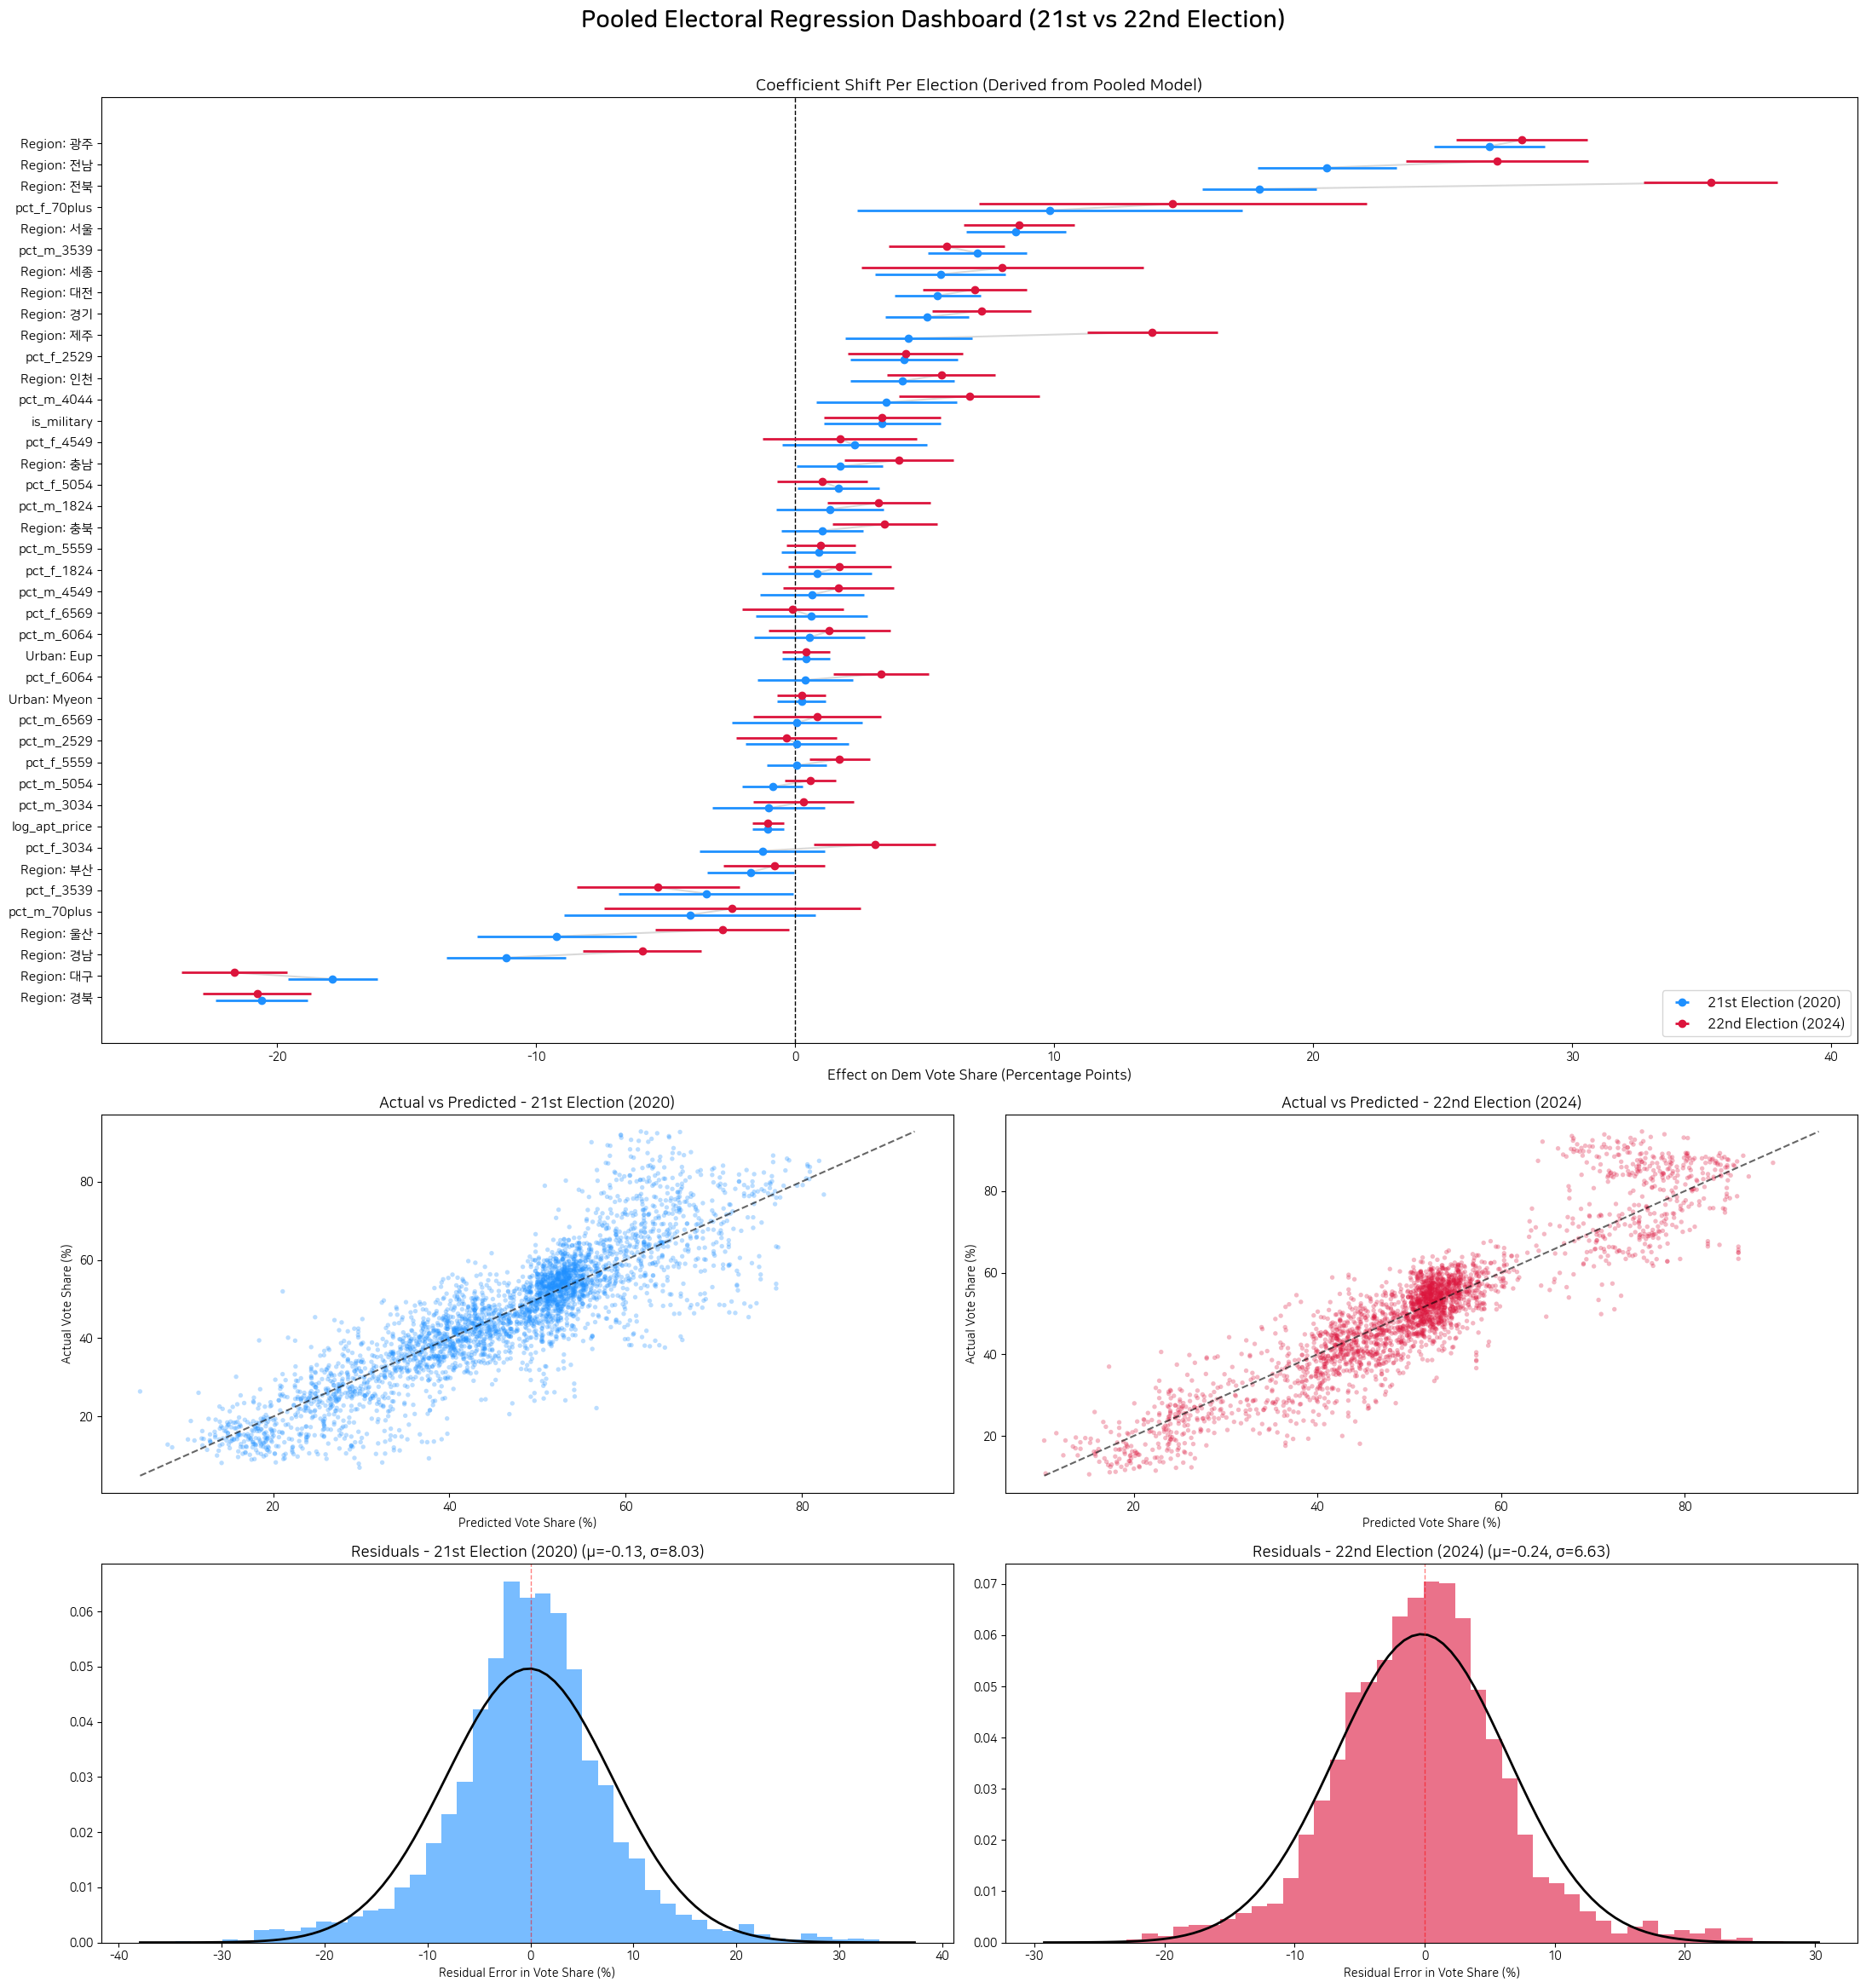

In [13]:
import pandas as pd
import numpy as np
import math
import os
import re
import glob
from difflib import get_close_matches
from scipy.stats import norm, probplot
import statsmodels.formula.api as smf
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

try:
    import koreanize_matplotlib
except ImportError:
    print("[!] koreanize_matplotlib not found. Run: pip install koreanize-matplotlib")

# ==========================================
# CONFIGURATION
# ==========================================
ELECTION_CONFIGS = {
    21: {
        'census_csv':    '21st_election_census.csv',
        'result_csv':    '21st_election_result.csv',
        'apt_csv_glob':  '*21st_election_*_apt_price.csv',
        'dem_pattern':   r'더불어민주당',
        'con_pattern':   r'미래통합당|자유한국당',
        'label':         '21st General Election (2020)'
    },
    22: {
        'census_csv':    '22nd_election_census.csv',
        'result_csv':    '22nd_election_result.csv',
        'apt_csv_glob':  '*22nd_election_*_apt_price.csv',
        'dem_pattern':   r'더불어민주당',
        'con_pattern':   r'국민의힘',
        'label':         '22nd General Election (2024)'
    },
}

SPECIAL_DONG_NAMES = {
    '거소·선상투표', '관외사전투표', '국외부재자투표',
    '국외부재자투표(공관)', '잘못 투입·구분된 투표지',
}

GWANNAESA_LABEL = '관내사전투표'
META_CANDIDATES = {'선거인수', '투표수', '무효 투표수', '기권자수'}

PROV_FULL_TO_SHORT = {
    '서울특별시': '서울', '부산광역시': '부산', '대구광역시': '대구',
    '인천광역시': '인천', '광주광역시': '광주', '대전광역시': '대전',
    '울산광역시': '울산', '세종특별자치시': '세종',
    '경기도': '경기', '강원도': '강원', '강원특별자치도': '강원',
    '충청북도': '충북', '충청남도': '충남',
    '전라북도': '전북', '전북특별자치도': '전북', '전라남도': '전남',
    '경상북도': '경북', '경상남도': '경남', '제주특별자치도': '제주',
}

AGE_GENDER_COLS = [
    'pct_m_1824', 'pct_m_2529', 'pct_m_3034', 'pct_m_3539', 'pct_m_4044', 'pct_m_4549',
    'pct_m_5054', 'pct_m_5559', 'pct_m_6064', 'pct_m_6569', 'pct_m_70plus',
    'pct_f_1824', 'pct_f_2529', 'pct_f_3034', 'pct_f_3539', 'pct_f_4044', 'pct_f_4549',
    'pct_f_5054', 'pct_f_5559', 'pct_f_6064', 'pct_f_6569', 'pct_f_70plus'
]

# ==========================================
# SHARED UTILITIES
# ==========================================
def normalize_dong_name(name: str) -> str:
    if not isinstance(name, str): return ""
    name = re.sub(r'\(.*?\)', '', name).strip().replace('.', '·')
    name = re.sub(r'제(\d)', r'\1', name)
    name = re.sub(r'·\d+', '', name)
    name = re.sub(r'(\d+)(동|읍|면)$', r'\2', name)
    return re.sub(r'\s+', ' ', name)

def split_admin_tokens(name: str) -> list:
    tokens, buf = [], []
    for ch in name:
        buf.append(ch)
        if ch in '시군구' and len(buf) >= 2:
            tokens.append(''.join(buf))
            buf = []
    if buf: tokens.append(''.join(buf))
    return [t for t in tokens if t]

def normalize_sigungu(name: str) -> list:
    if not isinstance(name, str): return []
    name = re.sub(r'\(.*?\)', '', name).strip()
    if not name: return []
    tokens = split_admin_tokens(name)
    if not tokens:
        stripped = re.sub(r'[시군구갑을병정무]$', '', name).strip()
        return [stripped] if stripped else []
    si_gun_count = sum(1 for t in tokens if t[-1] in '시군' and len(t) >= 2)
    gu_count     = sum(1 for t in tokens if t[-1] == '구' and len(t) >= 2)
    ordered = tokens if (si_gun_count >= 2 or (si_gun_count == 0 and gu_count >= 2)) else list(reversed(tokens))
    candidates = []
    for t in ordered:
        key = re.sub(r'[시군구]$', '', t).strip()
        if key and key not in candidates: candidates.append(key)
    return candidates

def get_urban_type(name: str) -> str:
    if pd.isna(name): return 'Unknown'
    name = str(name).strip()
    if re.search(r'(읍)\d*$', name): return 'Eup'
    elif re.search(r'(면)\d*$', name): return 'Myeon'
    else: return 'Dong'

def check_military_zone(row):
    sgg = str(row.get('area2_name', ''))
    dong = str(row.get('name', ''))
    military_dongs = [
        '진동면', '군내면', '장단면', '파평면', '중면', '장남면', '백학면', '왕징면',
        '근북면', '근동면', '원동면', '원남면', '임남면', '동송읍', '철원읍',
        '상서면', '서화면', '방산면', '해안면', '현내면',
        '백령면', '대청면', '연평면', '신도안면', '오천읍', '고경면'
    ]
    if any(m_dong in dong for m_dong in military_dongs): return 1
    if '진해구' in sgg: return 1
    return 0

# ==========================================
# DATA LOADERS
# ==========================================
def _detect_year_prefix(df: pd.DataFrame) -> str:
    for col in df.columns:
        m = re.match(r'(\d{4}년\d{2}월)_계_총인구수', col)
        if m: return m.group(1)
    raise ValueError("Cannot detect census year prefix.")

def load_census_csv(csv_path: str) -> pd.DataFrame:
    if not os.path.exists(csv_path): return pd.DataFrame()
    try:
        try: df = pd.read_csv(csv_path, encoding='utf-8', low_memory=False)
        except UnicodeDecodeError: df = pd.read_csv(csv_path, encoding='cp949', low_memory=False)

        prefix = _detect_year_prefix(df)
        voting_age_cols = ([f"{prefix}_계_{a}세" for a in range(18, 100)] + [f"{prefix}_계_100세 이상"])

        all_target_cols = list(voting_age_cols)
        for g in ['남', '여']:
            for a in range(18, 100):
                all_target_cols.append(f"{prefix}_{g}_{a}세")
            all_target_cols.append(f"{prefix}_{g}_100세 이상")

        for col in set(all_target_cols):
            if col in df.columns:
                df[col] = df[col].astype(str).str.replace(',', '', regex=False).pipe(pd.to_numeric, errors='coerce').fillna(0)

        df = df.copy()

        df['total_voting_pop'] = df[[c for c in voting_age_cols if c in df.columns]].sum(axis=1)
        df = df[df['total_voting_pop'] > 0].copy()

        ranges = [(18, 25, '1824'), (25, 30, '2529'), (30, 35, '3034'), (35, 40, '3539'),
                  (40, 45, '4044'), (45, 50, '4549'), (50, 55, '5054'), (55, 60, '5559'),
                  (60, 65, '6064'), (65, 70, '6569')]

        for g, g_str in [('남', 'm'), ('여', 'f')]:
            for r_start, r_end, r_str in ranges:
                cols = [f"{prefix}_{g}_{a}세" for a in range(r_start, r_end)]
                col_name = f'pct_{g_str}_{r_str}'
                df[col_name] = df[[c for c in cols if c in df.columns]].sum(axis=1) / df['total_voting_pop']

            cols_70 = [f"{prefix}_{g}_{a}세" for a in range(70, 100)] + [f"{prefix}_{g}_100세 이상"]
            col_name_70 = f'pct_{g_str}_70plus'
            df[col_name_70] = df[[c for c in cols_70 if c in df.columns]].sum(axis=1) / df['total_voting_pop']

        def extract_census_keys(admin_name):
            if not isinstance(admin_name, str): return [], ""
            clean = re.sub(r'\(.*?\)', '', admin_name).strip()
            parts = clean.split()
            dong_norm = normalize_dong_name(parts[-1]) if parts else ""
            sgg_cands = []
            for token in reversed(parts[:-1]):
                for c in normalize_sigungu(token):
                    if c not in sgg_cands: sgg_cands.append(c)
            return sgg_cands, dong_norm

        rows = []
        for _, row in df.iterrows():
            sgg_cands, dong_norm = extract_census_keys(row['행정구역'])
            row_dict = {
                'sgg_candidates': sgg_cands, 'primary_sgg': sgg_cands[0] if sgg_cands else "",
                'dong_norm': dong_norm, 'dong_raw': row['행정구역']
            }
            for col in AGE_GENDER_COLS:
                row_dict[col] = row.get(col, np.nan)
            rows.append(row_dict)

        return pd.DataFrame(rows)
    except Exception as e:
        print(f"[!] Error processing census CSV {csv_path}: {e}")
        return pd.DataFrame()

def load_apt_csv(glob_pattern: str) -> pd.DataFrame:
    file_list = glob.glob(glob_pattern)
    if not file_list: return pd.DataFrame()

    df_list = []
    for file in file_list:
        try:
            try: df_temp = pd.read_csv(file, encoding='utf-8', skiprows=15)
            except UnicodeDecodeError: df_temp = pd.read_csv(file, encoding='cp949', skiprows=15)
            df_list.append(df_temp)
        except Exception: pass

    if not df_list: return pd.DataFrame()
    df = pd.concat(df_list, ignore_index=True)

    try:
        df['거래금액(만원)'] = pd.to_numeric(df['거래금액(만원)'].astype(str).str.replace(',', '').str.strip(), errors='coerce')
        df['전용면적(㎡)'] = pd.to_numeric(df['전용면적(㎡)'], errors='coerce')
        df['price_per_sqm'] = df['거래금액(만원)'] / df['전용면적(㎡)']

        def parse_loc(x):
            parts = str(x).split()
            prov = PROV_FULL_TO_SHORT.get(parts[0], parts[0]) if len(parts) > 0 else ""
            if len(parts) > 2:
                sgg = normalize_sigungu(parts[1])[0] if normalize_sigungu(parts[1]) else ""
            else:
                sgg = ""
            dong = normalize_dong_name(parts[-1]) if len(parts) > 0 else ""
            return pd.Series([prov, sgg, dong])

        df[['prov', 'sgg', 'dong_norm']] = df['시군구'].apply(parse_loc)
        apt_agg = df.groupby(['prov', 'sgg', 'dong_norm'])['price_per_sqm'].median().reset_index()
        apt_agg.rename(columns={'price_per_sqm': 'median_apt_price_sqm'}, inplace=True)
        return apt_agg
    except Exception: return pd.DataFrame()

def load_election_csv(csv_path: str, dem_pattern: str, con_pattern: str):
    try:
        try: df = pd.read_csv(csv_path, encoding='utf-8', low_memory=False)
        except UnicodeDecodeError: df = pd.read_csv(csv_path, encoding='cp949', low_memory=False)
    except Exception: return pd.DataFrame()

    df['득표수']       = pd.to_numeric(df['득표수'], errors='coerce').fillna(0).astype(int)
    df['is_dem']      = df['후보자'].str.contains(dem_pattern, case=False, na=False)
    df['is_meta']     = df['후보자'].isin(META_CANDIDATES)

    dong_key  = ['시도명', '선거구명', '법정읍면동명']

    def sgg_cands_from_constituency(name):
        if not isinstance(name, str): return []
        if '_' in name: return normalize_sigungu(name.split('_', 1)[1])
        return normalize_sigungu(re.sub(r'[갑을병정무]$', '', name).strip())

    df_geo   = df[~df['법정읍면동명'].isin(SPECIAL_DONG_NAMES)].copy()
    df_votes = df_geo[~df_geo['is_meta']].copy()

    total_dem = df_votes[df_votes['is_dem']].groupby(dong_key)['득표수'].sum().reset_index(name='total_dem')
    total_votes = df_votes.groupby(dong_key)['득표수'].sum().reset_index(name='total_votes')
    sum_people_dong = df_geo[df_geo['후보자'] == '선거인수'].groupby(dong_key)['득표수'].sum().reset_index(name='sum_people')

    df_dong = total_dem.copy()
    for frame in (total_votes, sum_people_dong):
        df_dong = df_dong.merge(frame, on=dong_key, how='outer')
    df_dong = df_dong.fillna(0)

    df_dong['sgg_candidates'] = df_dong['선거구명'].apply(sgg_cands_from_constituency)
    df_dong['primary_sgg']    = df_dong['sgg_candidates'].apply(lambda x: x[0] if x else "")
    df_dong['dong_norm']      = df_dong['법정읍면동명'].apply(normalize_dong_name)
    df_dong['province_tag']   = df_dong['시도명'].map(PROV_FULL_TO_SHORT).fillna(df_dong['시도명'])
    df_dong['area2_name']     = df_dong['선거구명']
    df_dong['name']           = df_dong['법정읍면동명']
    df_dong['urban_type']     = df_dong['name'].apply(get_urban_type)
    df_dong['is_military']    = df_dong.apply(check_military_zone, axis=1)

    return df_dong

def merge_dong_with_covariates(df_election: pd.DataFrame, df_census: pd.DataFrame, df_apt: pd.DataFrame) -> pd.DataFrame:
    if not df_census.empty:
        census_lookup = {}; census_by_sgg = {}
        for _, row in df_census.iterrows():
            dnorm = row['dong_norm']
            covs = {c: row.get(c, np.nan) for c in AGE_GENDER_COLS}
            for sgg in row['sgg_candidates']:
                census_lookup[(sgg, dnorm)] = covs
                census_by_sgg.setdefault(sgg, []).append(dnorm)

        results = []
        for _, row in df_election.iterrows():
            covs = None
            dk = row['dong_norm']
            sgc = row['sgg_candidates'] if isinstance(row['sgg_candidates'], list) else [row['primary_sgg']]

            if (row['primary_sgg'], dk) in census_lookup: covs = census_lookup[(row['primary_sgg'], dk)]
            if covs is None and '·' in dk:
                k1b = (row['primary_sgg'], dk.replace('·', ''))
                if k1b in census_lookup: covs = census_lookup[k1b]
            if covs is None:
                for sgg in sgc[1:]:
                    if (sgg, dk) in census_lookup: covs = census_lookup[(sgg, dk)]; break
            if covs is None:
                for sgg in sgc:
                    pool = census_by_sgg.get(sgg, [])
                    if pool:
                        m = get_close_matches(dk, pool, n=1, cutoff=0.82)
                        if m and (sgg, m[0]) in census_lookup: covs = census_lookup[(sgg, m[0])]; break

            if covs is None: covs = {k: np.nan for k in AGE_GENDER_COLS}
            rd = row.to_dict(); rd.update(covs)
            results.append(rd)
        df_out = pd.DataFrame(results)
    else:
        df_out = df_election.copy()

    if not df_apt.empty:
        df_out = df_out.merge(df_apt, left_on=['province_tag', 'primary_sgg', 'dong_norm'], right_on=['prov', 'sgg', 'dong_norm'], how='left')
        sgg_med = df_out.groupby('primary_sgg')['median_apt_price_sqm'].transform('median')
        df_out['median_apt_price_sqm'] = df_out['median_apt_price_sqm'].fillna(sgg_med)
        prov_med = df_out.groupby('province_tag')['median_apt_price_sqm'].transform('median')
        df_out['median_apt_price_sqm'] = df_out['median_apt_price_sqm'].fillna(prov_med)
        df_out['median_apt_price_sqm'] = df_out['median_apt_price_sqm'].fillna(df_out['median_apt_price_sqm'].median())
        df_out['log_apt_price'] = np.log1p(df_out['median_apt_price_sqm'])
    else:
        df_out['log_apt_price'] = 0.0

    return df_out[df_out['pct_f_4044'].notna()].copy()

# ==========================================
# POOLED REGRESSION ENGINE
# ==========================================
def run_pooled_shift_regression(dm_21: pd.DataFrame, dm_22: pd.DataFrame) -> dict:
    MIN_VOTES = 50

    dm_21 = dm_21[(dm_21['total_votes'] > MIN_VOTES) & (dm_21['total_dem'] > 0)].copy()
    dm_21['is_22nd'] = 0

    dm_22 = dm_22[(dm_22['total_votes'] > MIN_VOTES) & (dm_22['total_dem'] > 0)].copy()
    dm_22['is_22nd'] = 1

    df_pooled = pd.concat([dm_21, dm_22], ignore_index=True)
    df_pooled['vote_share'] = df_pooled['total_dem'] / df_pooled['total_votes']

    model_age_gender_cols = [c for c in AGE_GENDER_COLS if c != 'pct_f_4044']
    req_cols = ['vote_share', 'is_22nd', 'province_tag', 'urban_type', 'is_military', 'sum_people', 'log_apt_price'] + AGE_GENDER_COLS
    df_mod = df_pooled.dropna(subset=req_cols).copy()

    cont_cols = model_age_gender_cols + ['log_apt_price']

    # --- NEW: Print the real-world standard deviations before scaling ---
    print("\n--- Standard Deviations of Continuous Variables (1 SD = ...) ---")
    for col in cont_cols:
        raw_sd = df_mod[col].std()
        if col.startswith('pct_'):
            print(f"  {col}: {raw_sd:.4f} ({raw_sd*100:.2f}%)")
        else:
            print(f"  {col}: {raw_sd:.4f}")
    print("--------------------------------------------------------------\n")

    scaler = StandardScaler()
    df_mod[cont_cols] = scaler.fit_transform(df_mod[cont_cols])

    base_covariates = f"{' + '.join(model_age_gender_cols)} + is_military + log_apt_price + C(province_tag) + C(urban_type)"
    national_shift = "is_22nd"
    regional_shift = "is_22nd:C(province_tag)"
    cohort_shift = " + ".join([f"is_22nd:{c}" for c in model_age_gender_cols])

    formula = f"vote_share ~ {base_covariates} + {national_shift} + {regional_shift} + {cohort_shift}"

    print("Fitting Pooled DiD-Style Regression Model...")
    model = smf.wls(formula, data=df_mod, weights=df_mod['sum_people']).fit(cov_type='HC3')

    print(f"Model R²: {model.rsquared*100:.2f}%")
    df_mod['residual'] = model.resid
    df_mod['fitted']   = model.fittedvalues

    return {'df': df_mod, 'model': model}

# ==========================================
# VISUALIZATION
# ==========================================
def plot_shift_dashboard(results: dict, out_path: str):
    model = results['model']
    df_mod = results['df']

    # ----------------------------------------------------
    # 1. EXTRACT COEFFICIENTS USING JOINT VARIANCE
    # ----------------------------------------------------
    params = model.params
    cov_mat = model.cov_params()

    # Identify base covariates (exclude Intercept and pure national shift term)
    base_names = [c for c in params.index if ':' not in c and c not in ['Intercept', 'is_22nd']]

    data = []
    for b in base_names:
        # --- NEW: Multiply by 100 to convert from proportion to percentage points ---
        est_21 = params[b] * 100
        se_21 = np.sqrt(cov_mat.loc[b, b]) * 100

        # Format the interaction column name correctly for statsmodels
        shift_col = f"is_22nd:{b}"

        if shift_col in params:
            est_shift = params[shift_col] * 100
            est_22 = est_21 + est_shift
            # Joint Variance: Var(A+B) = Var(A) + Var(B) + 2Cov(A,B)
            # The standard error is calculated, then multiplied by 100 for scaling.
            var_22 = cov_mat.loc[b, b] + cov_mat.loc[shift_col, shift_col] + 2 * cov_mat.loc[b, shift_col]
            se_22 = np.sqrt(var_22) * 100
        else:
            est_22 = est_21
            se_22 = se_21

        data.append({
            'feature': b,
            'est_21': est_21, 'err_21': 1.96 * se_21,
            'est_22': est_22, 'err_22': 1.96 * se_22
        })

    df_coef = pd.DataFrame(data).set_index('feature')

    # Clean index names for presentation
    df_coef.index = df_coef.index.str.replace('C(province_tag)[T.', 'Region: ', regex=False).str.replace(']', '', regex=False)
    df_coef.index = df_coef.index.str.replace('C(urban_type)[T.', 'Urban: ', regex=False).str.replace(']', '', regex=False)
    df_coef = df_coef.sort_values('est_21')

    # ----------------------------------------------------
    # 2. PLOTTING LAYOUT
    # ----------------------------------------------------
    fig = plt.figure(figsize=(22, 24))
    gs = fig.add_gridspec(3, 2, height_ratios=[2.5, 1, 1])
    fig.suptitle("Pooled Electoral Regression Dashboard (21st vs 22nd Election)", fontsize=20, fontweight='bold', y=0.97)

    # SUBPLOT 1: Coefficient Dumbbell Plot (Spans both columns)
    ax_coef = fig.add_subplot(gs[0, :])
    y_pos = np.arange(len(df_coef))

    # Plot connecting line to emphasize shift direction
    for i in range(len(df_coef)):
        ax_coef.plot([df_coef['est_21'].iloc[i], df_coef['est_22'].iloc[i]], [y_pos[i]-0.15, y_pos[i]+0.15], color='gray', alpha=0.3, zorder=1)

    # Plot 21st and 22nd point estimates with Error Bars
    ax_coef.errorbar(df_coef['est_21'], y_pos - 0.15, xerr=df_coef['err_21'], fmt='o', color='dodgerblue', markersize=6, elinewidth=2, label='21st Election (2020)', zorder=2)
    ax_coef.errorbar(df_coef['est_22'], y_pos + 0.15, xerr=df_coef['err_22'], fmt='o', color='crimson', markersize=6, elinewidth=2, label='22nd Election (2024)', zorder=3)

    ax_coef.axvline(0, color='black', linestyle='--', linewidth=1)
    ax_coef.set_yticks(y_pos)
    ax_coef.set_yticklabels(df_coef.index, fontsize=11)
    ax_coef.set_title(f'Coefficient Shift Per Election (Derived from Pooled Model)', fontsize=14)
    # --- NEW: Updated label to reflect percentage points ---
    ax_coef.set_xlabel('Effect on Dem Vote Share (Percentage Points)', fontsize=12)
    ax_coef.legend(fontsize=12, loc='lower right')

    # Data separation for predictive scatter/residuals
    df_21 = df_mod[df_mod['is_22nd'] == 0]
    df_22 = df_mod[df_mod['is_22nd'] == 1]

    # SUBPLOT 2 & 3: Actual vs Predicted
    def plot_avp(ax, df_sub, title_year, color):
        x = df_sub['fitted'] * 100
        y = df_sub['vote_share'] * 100
        ax.scatter(x, y, alpha=0.3, s=15, color=color, edgecolors='none')
        mn = min(x.min(), y.min())
        mx = max(x.max(), y.max())
        ax.plot([mn, mx], [mn, mx], 'k--', lw=1.5, alpha=0.6)
        ax.set_title(f'Actual vs Predicted - {title_year}', fontsize=13)
        ax.set_xlabel('Predicted Vote Share (%)', fontsize=10)
        ax.set_ylabel('Actual Vote Share (%)', fontsize=10)

    ax_avp_21 = fig.add_subplot(gs[1, 0])
    plot_avp(ax_avp_21, df_21, '21st Election (2020)', 'dodgerblue')

    ax_avp_22 = fig.add_subplot(gs[1, 1])
    plot_avp(ax_avp_22, df_22, '22nd Election (2024)', 'crimson')

    # SUBPLOT 4 & 5: Residuals
    def plot_res(ax, df_sub, title_year, color):
        res_data = df_sub['residual'] * 100
        ax.hist(res_data, bins=45, density=True, color=color, alpha=0.6)
        mu, std = res_data.mean(), res_data.std()
        xmin, xmax = ax.get_xlim()
        x_line = np.linspace(xmin, xmax, 100)
        p = norm.pdf(x_line, mu, std)
        ax.plot(x_line, p, 'k', linewidth=2)
        ax.axvline(0, color='red', lw=1, ls='--', alpha=0.5)
        ax.set_title(f'Residuals - {title_year} (μ={mu:.2f}, σ={std:.2f})', fontsize=13)
        ax.set_xlabel('Residual Error in Vote Share (%)', fontsize=10)

    ax_res_21 = fig.add_subplot(gs[2, 0])
    plot_res(ax_res_21, df_21, '21st Election (2020)', 'dodgerblue')

    ax_res_22 = fig.add_subplot(gs[2, 1])
    plot_res(ax_res_22, df_22, '22nd Election (2024)', 'crimson')

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig(out_path, dpi=200)
    print(f"Saved shift dashboard → '{out_path}'")

    # Save summary report
    report_out = out_path.replace('.png', '_report.txt')
    with open(report_out, 'w') as f:
        f.write(model.summary().as_text())
    print(f"Saved full statistical summary text → '{report_out}'")

# ==========================================
# EXECUTION
# ==========================================
if __name__ == "__main__":
    print(f"\n{'='*60}")
    print(f"  Korean Election Pooled Shift Model (21st vs 22nd)")
    print(f"{'='*60}")

    datasets = {}
    for year, cfg in ELECTION_CONFIGS.items():
        print(f"\n--- Loading {cfg['label']} ---")
        df_cen = load_census_csv(cfg['census_csv'])
        df_apt = load_apt_csv(cfg['apt_csv_glob'])
        df_elec = load_election_csv(cfg['result_csv'], cfg['dem_pattern'], cfg['con_pattern'])

        if not df_elec.empty:
            datasets[year] = merge_dong_with_covariates(df_elec, df_cen, df_apt)
            print(f"    Merged {len(datasets[year])} districts for {year}st/nd election.")

    if 21 in datasets and 22 in datasets:
        results = run_pooled_shift_regression(datasets[21], datasets[22])
        plot_shift_dashboard(results, out_path='pooled_electoral_dashboard.png')
    else:
        print("[!] Missing data for one or both elections. Cannot run pooled model.")

[!] koreanize_matplotlib not found. Run: pip install koreanize-matplotlib

  Korean Election Pooled Shift Model (21st vs 22nd)

--- Loading 21st General Election (2020) ---
    Merged 3480 districts for 21st/nd election.

--- Loading 22nd General Election (2024) ---
    Merged 2847 districts for 22st/nd election.

Fitting Pooled DiD-Style Regression Model...
Model R²: 76.85%
Saved shift dashboard → 'pooled_electoral_shifts.png'
Saved full statistical summary text → 'pooled_electoral_shifts_report.txt'


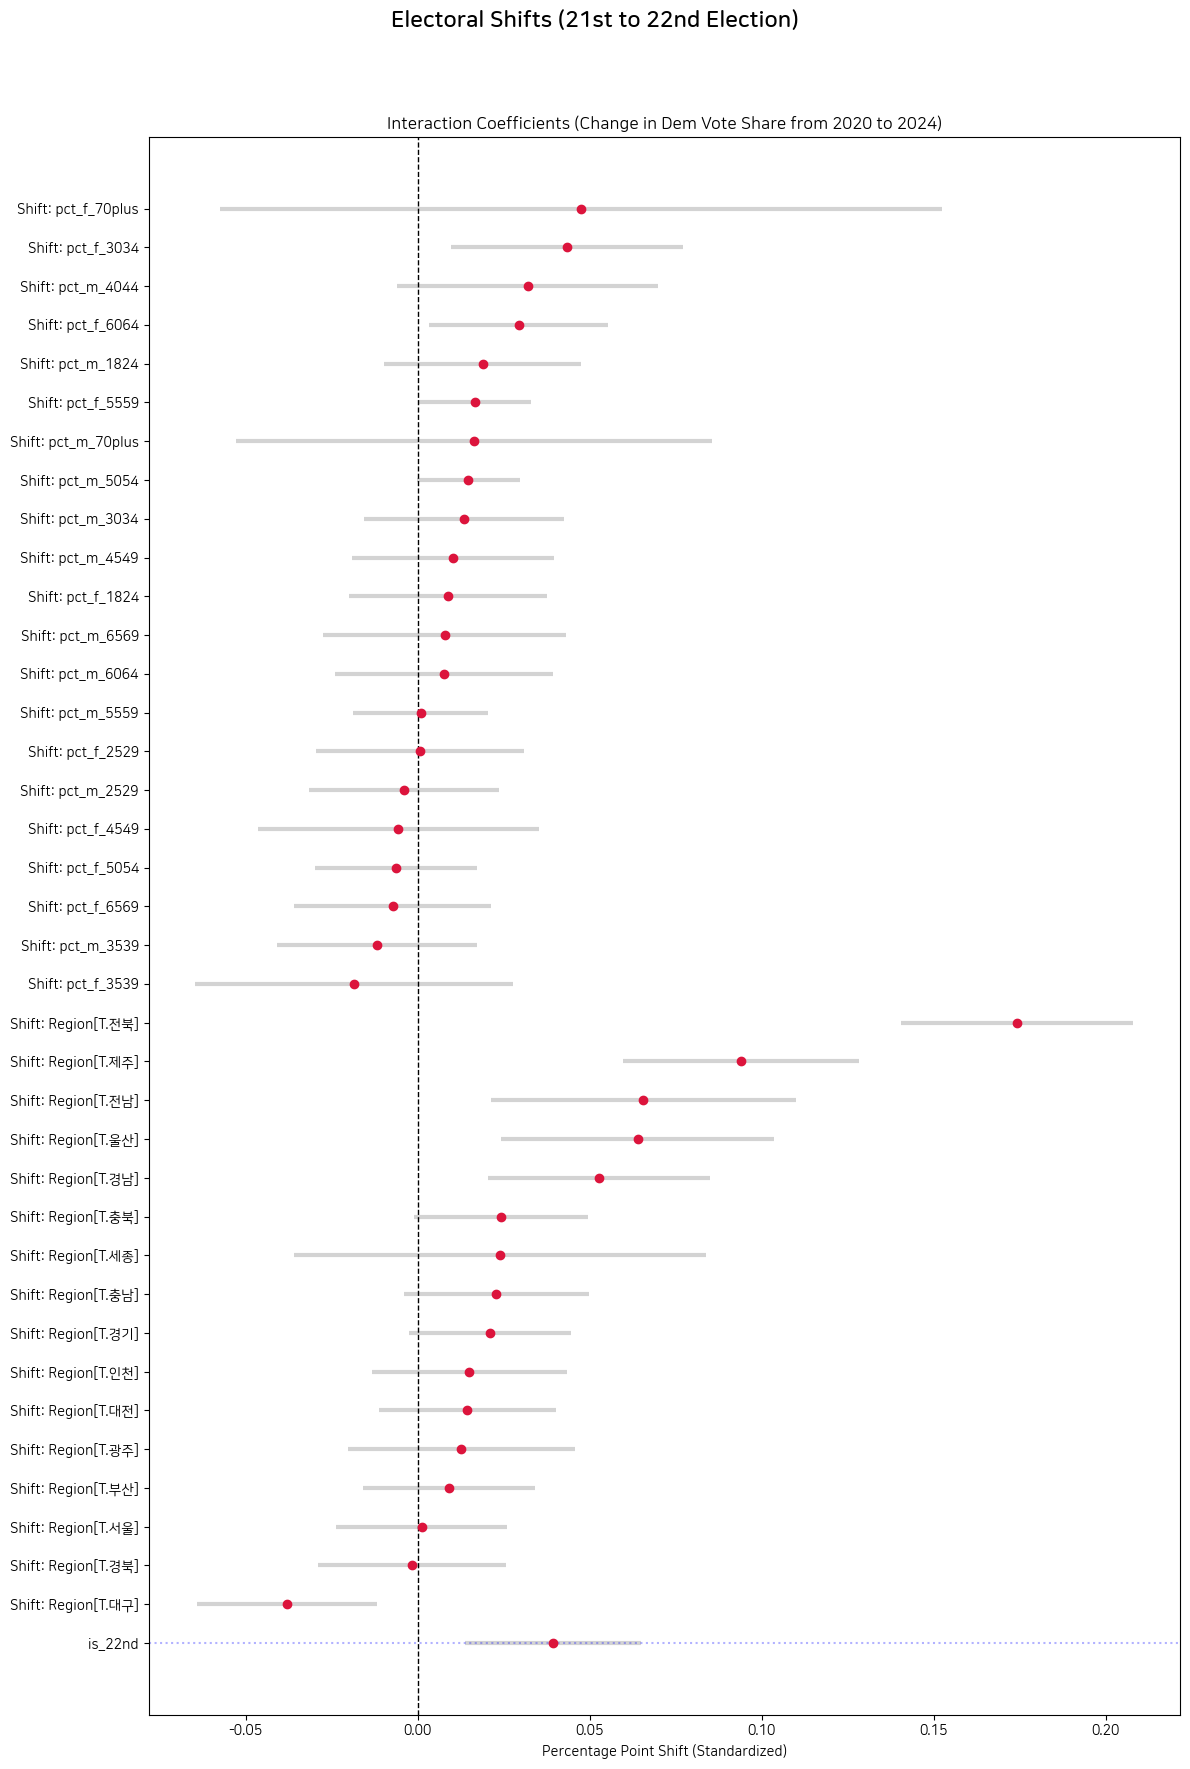

In [14]:
import pandas as pd
import numpy as np
import math
import os
import re
import glob
from difflib import get_close_matches
from scipy.stats import norm, probplot
import statsmodels.formula.api as smf
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

try:
    import koreanize_matplotlib
except ImportError:
    print("[!] koreanize_matplotlib not found. Run: pip install koreanize-matplotlib")

# ==========================================
# CONFIGURATION
# ==========================================
ELECTION_CONFIGS = {
    21: {
        'census_csv':    '21st_election_census.csv',
        'result_csv':    '21st_election_result.csv',
        'apt_csv_glob':  '*21st_election_*_apt_price.csv',
        'dem_pattern':   r'더불어민주당',
        'con_pattern':   r'미래통합당|자유한국당',
        'label':         '21st General Election (2020)'
    },
    22: {
        'census_csv':    '22nd_election_census.csv',
        'result_csv':    '22nd_election_result.csv',
        'apt_csv_glob':  '*22nd_election_*_apt_price.csv',
        'dem_pattern':   r'더불어민주당',
        'con_pattern':   r'국민의힘',
        'label':         '22nd General Election (2024)'
    },
}

SPECIAL_DONG_NAMES = {
    '거소·선상투표', '관외사전투표', '국외부재자투표',
    '국외부재자투표(공관)', '잘못 투입·구분된 투표지',
}

GWANNAESA_LABEL = '관내사전투표'
META_CANDIDATES = {'선거인수', '투표수', '무효 투표수', '기권자수'}

PROV_FULL_TO_SHORT = {
    '서울특별시': '서울', '부산광역시': '부산', '대구광역시': '대구',
    '인천광역시': '인천', '광주광역시': '광주', '대전광역시': '대전',
    '울산광역시': '울산', '세종특별자치시': '세종',
    '경기도': '경기', '강원도': '강원', '강원특별자치도': '강원',
    '충청북도': '충북', '충청남도': '충남',
    '전라북도': '전북', '전북특별자치도': '전북', '전라남도': '전남',
    '경상북도': '경북', '경상남도': '경남', '제주특별자치도': '제주',
}

AGE_GENDER_COLS = [
    'pct_m_1824', 'pct_m_2529', 'pct_m_3034', 'pct_m_3539', 'pct_m_4044', 'pct_m_4549',
    'pct_m_5054', 'pct_m_5559', 'pct_m_6064', 'pct_m_6569', 'pct_m_70plus',
    'pct_f_1824', 'pct_f_2529', 'pct_f_3034', 'pct_f_3539', 'pct_f_4044', 'pct_f_4549',
    'pct_f_5054', 'pct_f_5559', 'pct_f_6064', 'pct_f_6569', 'pct_f_70plus'
]

# ==========================================
# SHARED UTILITIES
# ==========================================
def normalize_dong_name(name: str) -> str:
    if not isinstance(name, str): return ""
    name = re.sub(r'\(.*?\)', '', name).strip().replace('.', '·')
    name = re.sub(r'제(\d)', r'\1', name)
    name = re.sub(r'·\d+', '', name)
    name = re.sub(r'(\d+)(동|읍|면)$', r'\2', name)
    return re.sub(r'\s+', ' ', name)

def split_admin_tokens(name: str) -> list:
    tokens, buf = [], []
    for ch in name:
        buf.append(ch)
        if ch in '시군구' and len(buf) >= 2:
            tokens.append(''.join(buf))
            buf = []
    if buf: tokens.append(''.join(buf))
    return [t for t in tokens if t]

def normalize_sigungu(name: str) -> list:
    if not isinstance(name, str): return []
    name = re.sub(r'\(.*?\)', '', name).strip()
    if not name: return []
    tokens = split_admin_tokens(name)
    if not tokens:
        stripped = re.sub(r'[시군구갑을병정무]$', '', name).strip()
        return [stripped] if stripped else []
    si_gun_count = sum(1 for t in tokens if t[-1] in '시군' and len(t) >= 2)
    gu_count     = sum(1 for t in tokens if t[-1] == '구' and len(t) >= 2)
    ordered = tokens if (si_gun_count >= 2 or (si_gun_count == 0 and gu_count >= 2)) else list(reversed(tokens))
    candidates = []
    for t in ordered:
        key = re.sub(r'[시군구]$', '', t).strip()
        if key and key not in candidates: candidates.append(key)
    return candidates

def get_urban_type(name: str) -> str:
    if pd.isna(name): return 'Unknown'
    name = str(name).strip()
    if re.search(r'(읍)\d*$', name): return 'Eup'
    elif re.search(r'(면)\d*$', name): return 'Myeon'
    else: return 'Dong'

def check_military_zone(row):
    sgg = str(row.get('area2_name', ''))
    dong = str(row.get('name', ''))
    military_dongs = [
        '진동면', '군내면', '장단면', '파평면', '중면', '장남면', '백학면', '왕징면',
        '근북면', '근동면', '원동면', '원남면', '임남면', '동송읍', '철원읍',
        '상서면', '서화면', '방산면', '해안면', '현내면',
        '백령면', '대청면', '연평면', '신도안면', '오천읍', '고경면'
    ]
    if any(m_dong in dong for m_dong in military_dongs): return 1
    if '진해구' in sgg: return 1
    return 0

# ==========================================
# DATA LOADERS
# ==========================================
def _detect_year_prefix(df: pd.DataFrame) -> str:
    for col in df.columns:
        m = re.match(r'(\d{4}년\d{2}월)_계_총인구수', col)
        if m: return m.group(1)
    raise ValueError("Cannot detect census year prefix.")

def load_census_csv(csv_path: str) -> pd.DataFrame:
    if not os.path.exists(csv_path): return pd.DataFrame()
    try:
        try: df = pd.read_csv(csv_path, encoding='utf-8', low_memory=False)
        except UnicodeDecodeError: df = pd.read_csv(csv_path, encoding='cp949', low_memory=False)

        prefix = _detect_year_prefix(df)

        # Total voting population (18+)
        voting_age_cols = ([f"{prefix}_계_{a}세" for a in range(18, 100)] + [f"{prefix}_계_100세 이상"])

        # Target all columns we need to clean (totals + male + female)
        all_target_cols = list(voting_age_cols)
        for g in ['남', '여']:
            for a in range(18, 100):
                all_target_cols.append(f"{prefix}_{g}_{a}세")
            all_target_cols.append(f"{prefix}_{g}_100세 이상")

        # Clean the commas column by column
        for col in set(all_target_cols):
            if col in df.columns:
                df[col] = df[col].astype(str).str.replace(',', '', regex=False).pipe(pd.to_numeric, errors='coerce').fillna(0)

        # De-fragment the DataFrame memory to silence the PerformanceWarning
        df = df.copy()

        # Now sum the cleaned columns
        df['total_voting_pop'] = df[[c for c in voting_age_cols if c in df.columns]].sum(axis=1)
        df = df[df['total_voting_pop'] > 0].copy()

        ranges = [(18, 25, '1824'), (25, 30, '2529'), (30, 35, '3034'), (35, 40, '3539'),
                  (40, 45, '4044'), (45, 50, '4549'), (50, 55, '5054'), (55, 60, '5559'),
                  (60, 65, '6064'), (65, 70, '6569')]

        for g, g_str in [('남', 'm'), ('여', 'f')]:
            for r_start, r_end, r_str in ranges:
                cols = [f"{prefix}_{g}_{a}세" for a in range(r_start, r_end)]
                col_name = f'pct_{g_str}_{r_str}'
                df[col_name] = df[[c for c in cols if c in df.columns]].sum(axis=1) / df['total_voting_pop']

            cols_70 = [f"{prefix}_{g}_{a}세" for a in range(70, 100)] + [f"{prefix}_{g}_100세 이상"]
            col_name_70 = f'pct_{g_str}_70plus'
            df[col_name_70] = df[[c for c in cols_70 if c in df.columns]].sum(axis=1) / df['total_voting_pop']

        def extract_census_keys(admin_name):
            if not isinstance(admin_name, str): return [], ""
            clean = re.sub(r'\(.*?\)', '', admin_name).strip()
            parts = clean.split()
            dong_norm = normalize_dong_name(parts[-1]) if parts else ""
            sgg_cands = []
            for token in reversed(parts[:-1]):
                for c in normalize_sigungu(token):
                    if c not in sgg_cands: sgg_cands.append(c)
            return sgg_cands, dong_norm

        rows = []
        for _, row in df.iterrows():
            sgg_cands, dong_norm = extract_census_keys(row['행정구역'])
            row_dict = {
                'sgg_candidates': sgg_cands, 'primary_sgg': sgg_cands[0] if sgg_cands else "",
                'dong_norm': dong_norm, 'dong_raw': row['행정구역']
            }
            for col in AGE_GENDER_COLS:
                row_dict[col] = row.get(col, np.nan)
            rows.append(row_dict)

        return pd.DataFrame(rows)
    except Exception as e:
        print(f"[!] Error processing census CSV {csv_path}: {e}")
        return pd.DataFrame()

def load_apt_csv(glob_pattern: str) -> pd.DataFrame:
    file_list = glob.glob(glob_pattern)
    if not file_list: return pd.DataFrame()

    df_list = []
    for file in file_list:
        try:
            try: df_temp = pd.read_csv(file, encoding='utf-8', skiprows=15)
            except UnicodeDecodeError: df_temp = pd.read_csv(file, encoding='cp949', skiprows=15)
            df_list.append(df_temp)
        except Exception: pass

    if not df_list: return pd.DataFrame()
    df = pd.concat(df_list, ignore_index=True)

    try:
        df['거래금액(만원)'] = pd.to_numeric(df['거래금액(만원)'].astype(str).str.replace(',', '').str.strip(), errors='coerce')
        df['전용면적(㎡)'] = pd.to_numeric(df['전용면적(㎡)'], errors='coerce')
        df['price_per_sqm'] = df['거래금액(만원)'] / df['전용면적(㎡)']

        def parse_loc(x):
            parts = str(x).split()
            prov = PROV_FULL_TO_SHORT.get(parts[0], parts[0]) if len(parts) > 0 else ""
            if len(parts) > 2:
                sgg = normalize_sigungu(parts[1])[0] if normalize_sigungu(parts[1]) else ""
            else:
                sgg = ""
            dong = normalize_dong_name(parts[-1]) if len(parts) > 0 else ""
            return pd.Series([prov, sgg, dong])

        df[['prov', 'sgg', 'dong_norm']] = df['시군구'].apply(parse_loc)
        apt_agg = df.groupby(['prov', 'sgg', 'dong_norm'])['price_per_sqm'].median().reset_index()
        apt_agg.rename(columns={'price_per_sqm': 'median_apt_price_sqm'}, inplace=True)
        return apt_agg
    except Exception: return pd.DataFrame()

def load_election_csv(csv_path: str, dem_pattern: str, con_pattern: str):
    try:
        try: df = pd.read_csv(csv_path, encoding='utf-8', low_memory=False)
        except UnicodeDecodeError: df = pd.read_csv(csv_path, encoding='cp949', low_memory=False)
    except Exception: return pd.DataFrame()

    df['득표수']       = pd.to_numeric(df['득표수'], errors='coerce').fillna(0).astype(int)
    df['is_dem']      = df['후보자'].str.contains(dem_pattern, case=False, na=False)
    df['is_meta']     = df['후보자'].isin(META_CANDIDATES)

    dong_key  = ['시도명', '선거구명', '법정읍면동명']

    def sgg_cands_from_constituency(name):
        if not isinstance(name, str): return []
        if '_' in name: return normalize_sigungu(name.split('_', 1)[1])
        return normalize_sigungu(re.sub(r'[갑을병정무]$', '', name).strip())

    df_geo   = df[~df['법정읍면동명'].isin(SPECIAL_DONG_NAMES)].copy()
    df_votes = df_geo[~df_geo['is_meta']].copy()

    total_dem = df_votes[df_votes['is_dem']].groupby(dong_key)['득표수'].sum().reset_index(name='total_dem')
    total_votes = df_votes.groupby(dong_key)['득표수'].sum().reset_index(name='total_votes')
    sum_people_dong = df_geo[df_geo['후보자'] == '선거인수'].groupby(dong_key)['득표수'].sum().reset_index(name='sum_people')

    df_dong = total_dem.copy()
    for frame in (total_votes, sum_people_dong):
        df_dong = df_dong.merge(frame, on=dong_key, how='outer')
    df_dong = df_dong.fillna(0)

    df_dong['sgg_candidates'] = df_dong['선거구명'].apply(sgg_cands_from_constituency)
    df_dong['primary_sgg']    = df_dong['sgg_candidates'].apply(lambda x: x[0] if x else "")
    df_dong['dong_norm']      = df_dong['법정읍면동명'].apply(normalize_dong_name)
    df_dong['province_tag']   = df_dong['시도명'].map(PROV_FULL_TO_SHORT).fillna(df_dong['시도명'])
    df_dong['area2_name']     = df_dong['선거구명']
    df_dong['name']           = df_dong['법정읍면동명']
    df_dong['urban_type']     = df_dong['name'].apply(get_urban_type)
    df_dong['is_military']    = df_dong.apply(check_military_zone, axis=1)

    return df_dong

def merge_dong_with_covariates(df_election: pd.DataFrame, df_census: pd.DataFrame, df_apt: pd.DataFrame) -> pd.DataFrame:
    if not df_census.empty:
        census_lookup = {}; census_by_sgg = {}
        for _, row in df_census.iterrows():
            dnorm = row['dong_norm']
            covs = {c: row.get(c, np.nan) for c in AGE_GENDER_COLS}
            for sgg in row['sgg_candidates']:
                census_lookup[(sgg, dnorm)] = covs
                census_by_sgg.setdefault(sgg, []).append(dnorm)

        results = []
        for _, row in df_election.iterrows():
            covs = None
            dk = row['dong_norm']
            sgc = row['sgg_candidates'] if isinstance(row['sgg_candidates'], list) else [row['primary_sgg']]

            if (row['primary_sgg'], dk) in census_lookup: covs = census_lookup[(row['primary_sgg'], dk)]
            if covs is None and '·' in dk:
                k1b = (row['primary_sgg'], dk.replace('·', ''))
                if k1b in census_lookup: covs = census_lookup[k1b]
            if covs is None:
                for sgg in sgc[1:]:
                    if (sgg, dk) in census_lookup: covs = census_lookup[(sgg, dk)]; break
            if covs is None:
                for sgg in sgc:
                    pool = census_by_sgg.get(sgg, [])
                    if pool:
                        m = get_close_matches(dk, pool, n=1, cutoff=0.82)
                        if m and (sgg, m[0]) in census_lookup: covs = census_lookup[(sgg, m[0])]; break

            if covs is None: covs = {k: np.nan for k in AGE_GENDER_COLS}
            rd = row.to_dict(); rd.update(covs)
            results.append(rd)
        df_out = pd.DataFrame(results)
    else:
        df_out = df_election.copy()

    if not df_apt.empty:
        df_out = df_out.merge(df_apt, left_on=['province_tag', 'primary_sgg', 'dong_norm'], right_on=['prov', 'sgg', 'dong_norm'], how='left')
        sgg_med = df_out.groupby('primary_sgg')['median_apt_price_sqm'].transform('median')
        df_out['median_apt_price_sqm'] = df_out['median_apt_price_sqm'].fillna(sgg_med)
        prov_med = df_out.groupby('province_tag')['median_apt_price_sqm'].transform('median')
        df_out['median_apt_price_sqm'] = df_out['median_apt_price_sqm'].fillna(prov_med)
        df_out['median_apt_price_sqm'] = df_out['median_apt_price_sqm'].fillna(df_out['median_apt_price_sqm'].median())
        df_out['log_apt_price'] = np.log1p(df_out['median_apt_price_sqm'])
    else:
        df_out['log_apt_price'] = 0.0

    return df_out[df_out['pct_f_4044'].notna()].copy()

# ==========================================
# POOLED REGRESSION ENGINE
# ==========================================
def run_pooled_shift_regression(dm_21: pd.DataFrame, dm_22: pd.DataFrame) -> dict:
    MIN_VOTES = 50

    # Clean and flag 21st Election
    dm_21 = dm_21[(dm_21['total_votes'] > MIN_VOTES) & (dm_21['total_dem'] > 0)].copy()
    dm_21['is_22nd'] = 0

    # Clean and flag 22nd Election
    dm_22 = dm_22[(dm_22['total_votes'] > MIN_VOTES) & (dm_22['total_dem'] > 0)].copy()
    dm_22['is_22nd'] = 1

    # Stack datasets
    df_pooled = pd.concat([dm_21, dm_22], ignore_index=True)
    df_pooled['vote_share'] = df_pooled['total_dem'] / df_pooled['total_votes']

    # We exclude pct_f_4044 to avoid the dummy variable trap
    model_age_gender_cols = [c for c in AGE_GENDER_COLS if c != 'pct_f_4044']
    req_cols = ['vote_share', 'is_22nd', 'province_tag', 'urban_type', 'is_military', 'sum_people', 'log_apt_price'] + AGE_GENDER_COLS
    df_mod = df_pooled.dropna(subset=req_cols).copy()

    # Standardize continuous variables ON THE POOLED DATA
    scaler = StandardScaler()
    cont_cols = model_age_gender_cols + ['log_apt_price']
    df_mod[cont_cols] = scaler.fit_transform(df_mod[cont_cols])

    # Formula Construction
    base_covariates = f"{' + '.join(model_age_gender_cols)} + is_military + log_apt_price + C(province_tag) + C(urban_type)"
    national_shift = "is_22nd"
    regional_shift = "is_22nd:C(province_tag)"
    cohort_shift = " + ".join([f"is_22nd:{c}" for c in model_age_gender_cols])

    formula = f"vote_share ~ {base_covariates} + {national_shift} + {regional_shift} + {cohort_shift}"

    print("\nFitting Pooled DiD-Style Regression Model...")
    model = smf.wls(formula, data=df_mod, weights=df_mod['sum_people']).fit(cov_type='HC3')

    print(f"Model R²: {model.rsquared*100:.2f}%")
    df_mod['residual'] = model.resid
    df_mod['fitted']   = model.fittedvalues

    return {'df': df_mod, 'model': model}

# ==========================================
# VISUALIZATION
# ==========================================
def plot_shift_dashboard(results: dict, out_path: str):
    model = results['model']

    # Extract Shift Coefficients (interaction terms only)
    params = model.params
    conf = model.conf_int()
    errors = params - conf[0]

    # Filter only for the 'is_22nd' coefficients to see the shifts
    shift_params = params[params.index.str.contains('is_22nd')]
    shift_errors = errors[shift_params.index]

    # Separate into National, Regional, and Cohort for clean plotting
    nat_param = shift_params[['is_22nd']]
    reg_params = shift_params[shift_params.index.str.contains('province_tag')]
    coh_params = shift_params[~shift_params.index.str.contains('province_tag')].drop('is_22nd', errors='ignore')

    # Sort them
    reg_params = reg_params.sort_values()
    coh_params = coh_params.sort_values()

    sorted_shift_params = pd.concat([nat_param, reg_params, coh_params])
    sorted_shift_errors = shift_errors[sorted_shift_params.index]

    fig, ax = plt.subplots(figsize=(12, 18))
    fig.suptitle("Electoral Shifts (21st to 22nd Election)", fontsize=16, fontweight='bold', y=0.98)

    ax.errorbar(sorted_shift_params.values, range(len(sorted_shift_params)), xerr=sorted_shift_errors.values,
                 fmt='o', color='crimson', ecolor='lightgray', elinewidth=3, capsize=0)
    ax.axvline(0, color='black', linestyle='--', linewidth=1)

    # Highlight the National Shift line
    ax.axhline(0, color='blue', linestyle=':', alpha=0.3)

    ax.set_yticks(range(len(sorted_shift_params)))
    # Clean up labels for readability
    clean_labels = sorted_shift_params.index.str.replace('is_22nd:', 'Shift: ').str.replace('C(province_tag)', 'Region')
    ax.set_yticklabels(clean_labels, fontsize=10)

    ax.set_title('Interaction Coefficients (Change in Dem Vote Share from 2020 to 2024)', fontsize=12)
    ax.set_xlabel('Percentage Point Shift (Standardized)', fontsize=10)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.savefig(out_path, dpi=200)
    print(f"Saved shift dashboard → '{out_path}'")

    # Save summary report
    report_out = out_path.replace('.png', '_report.txt')
    with open(report_out, 'w') as f:
        f.write(model.summary().as_text())
    print(f"Saved full statistical summary text → '{report_out}'")

# ==========================================
# EXECUTION
# ==========================================
if __name__ == "__main__":
    print(f"\n{'='*60}")
    print(f"  Korean Election Pooled Shift Model (21st vs 22nd)")
    print(f"{'='*60}")

    datasets = {}
    for year, cfg in ELECTION_CONFIGS.items():
        print(f"\n--- Loading {cfg['label']} ---")
        df_cen = load_census_csv(cfg['census_csv'])
        df_apt = load_apt_csv(cfg['apt_csv_glob'])
        df_elec = load_election_csv(cfg['result_csv'], cfg['dem_pattern'], cfg['con_pattern'])

        if not df_elec.empty:
            datasets[year] = merge_dong_with_covariates(df_elec, df_cen, df_apt)
            print(f"    Merged {len(datasets[year])} districts for {year}st/nd election.")

    if 21 in datasets and 22 in datasets:
        results = run_pooled_shift_regression(datasets[21], datasets[22])
        plot_shift_dashboard(results, out_path='pooled_electoral_shifts.png')
    else:
        print("[!] Missing data for one or both elections. Cannot run pooled model.")